# 🌐 Assistente Diversa — Educação Inclusiva
## Proposta final - TCC

Grupo: Hélice

Participantes:
- Brena Oliveira
- Cesar Ricciarelli
- João Pedro Maranhão
- Leandro Nascimento
- Nícolas Pinotti

## 1. Instalação de dependências



In [53]:
%pip install -U beautifulsoup4 gradio pandas scikit-learn requests python-dotenv

print("✅ Instalação concluída!")
print()
print("Bibliotecas usadas no projeto:")
print("  • gradio     — interface web do chatbot")
print("  • requests   — chamadas HTTP para a Groq")
print("  • pandas     — manipulação da base de dados")
print("  • sklearn    — TF-IDF e busca por similaridade")



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Instalação concluída!

Bibliotecas usadas no projeto:
  • gradio     — interface web do chatbot
  • requests   — chamadas HTTP para a Groq
  • pandas     — manipulação da base de dados
  • sklearn    — TF-IDF e busca por similaridade


## 2. Importações e configuração



Carregamento da chave de API do GROQ devidamente configurada com proteção através do .env (exluso na configuração de .gitignore).

In [54]:
import json
import os
import re
import time
from typing import Dict, List

import gradio as gr
import pandas as pd
import requests
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv

load_dotenv()
GROQ_KEY = os.getenv("GROQ_KEY", "")

GROQ_MODEL = "openai/gpt-oss-20b"
GROQ_URL = "https://api.groq.com/openai/v1/chat/completions"

PARAMS_GERACAO = {
    "model": GROQ_MODEL,
    "max_tokens": 600,
    "temperature": 0.3,
    "top_p": 0.9,
}

print("✅ Configuração carregada")
print("Modelo:", GROQ_MODEL)
print("Modo:", "Groq/Llama" if GROQ_KEY else "Demonstração sem API")

✅ Configuração carregada
Modelo: openai/gpt-oss-20b
Modo: Groq/Llama


## 3. Base de conhecimento


Os dados se encontram hospedados no google docs, onde os registros ficam mais seguros e o código fica mais limpo.

In [55]:
import pandas as pd

SHEET_ID = "1Ll0gKNxMs20rMAESmjk4Dk2_FAtugKgY5NUhwaod1rI" 
URL_PLANILHA = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

artigos_brutos = pd.read_csv(URL_PLANILHA)

print("Linhas x Colunas =", artigos_brutos.shape)


print("\nColunas presentes na base de dados:")
print(list(artigos_brutos.columns))
print()

print("5 primeiras linhas")
display(artigos_brutos.head())

print(f"Todos os objetos são de texto:")
display(artigos_brutos.dtypes)

Linhas x Colunas = (36, 4)

Colunas presentes na base de dados:
['titulo', 'url', 'texto', 'artigo_completo']

5 primeiras linhas


,titulo,url,texto,artigo_completo
0,TEA na educação infantil: inclusão e afetivida...,https://diversa.org.br/artigos/tea-educacao-in...,O artigo apresenta estratégias que podem apoia...,Renata Pantaleão Ubugata Publicado em 03/10/20...
1,Ferramentas para o desenvolvimento escolar de ...,https://diversa.org.br/artigos/ferramentas-par...,O artigo aborda estratégias para apoiar a apre...,Emanoele Freitas Publicado em 03/04/2023\nEm c...
2,O que é Transtorno do Déficit de Atenção e Hip...,https://diversa.org.br/artigos/o-que-e-transto...,O artigo explica o Transtorno do Déficit de At...,Priscila Romero Publicado em 13/07/2023\nDia 1...
3,Como a escola pode lidar com os diagnósticos m...,https://diversa.org.br/artigos/como-a-escola-p...,O artigo explica o Transtorno do Déficit de At...,Patrícia de Brito Publicado em 19/04/2019\nDe ...
4,Psicomotricidade como recurso para a educação ...,https://diversa.org.br/artigos/psicomotricidad...,O artigo propõe uma reflexão cuidadosa sobre d...,"Caroline Lago, Cristiana Crespo e Lucas Bragan..."


Todos os objetos são de texto:


titulo             str
url                str
texto              str
artigo_completo    str
dtype: object

## 4. Limpeza da base



In [56]:
def limpar_texto(texto):
    texto = re.sub(r"\s+", " ", str(texto))
    texto = re.sub(r"\[.*?\]", "", texto)
    texto = re.sub(r"http\S+", "", texto)
    return texto.strip()

df = pd.DataFrame(artigos_brutos)
df["texto_limpo"] = df["artigo_completo"].apply(limpar_texto)
df = df[df["texto_limpo"].str.len() > 120].reset_index(drop=True)
df["conteudo_busca"] = df["titulo"] + ". " + df["titulo"] + ". " + df["texto_limpo"]

print("✅ Limpeza concluída")
print("Total de artigos válidos:", len(df))
display(df[["titulo", "url"]])

✅ Limpeza concluída
Total de artigos válidos: 20


,titulo,url
0,TEA na educação infantil: inclusão e afetivida...,https://diversa.org.br/artigos/tea-educacao-in...
1,Ferramentas para o desenvolvimento escolar de ...,https://diversa.org.br/artigos/ferramentas-par...
2,O que é Transtorno do Déficit de Atenção e Hip...,https://diversa.org.br/artigos/o-que-e-transto...
3,Como a escola pode lidar com os diagnósticos m...,https://diversa.org.br/artigos/como-a-escola-p...
4,Psicomotricidade como recurso para a educação ...,https://diversa.org.br/artigos/psicomotricidad...
5,Braile: acessibilidade para estudantes com def...,https://diversa.org.br/noticias/braile-acessib...
6,Educação de surdos: os desafios da proposta bi...,https://diversa.org.br/artigos/educacao-de-sur...
7,Qual o papel do Tradutor/Intérprete de Libras ...,https://diversa.org.br/artigos/qual-o-papel-do...
8,Flexibilizações vs. adaptações curriculares: c...,https://diversa.org.br/artigos/flexibilizacoes...
9,Os desafios de ser uma mulher com deficiência ...,https://diversa.org.br/artigos/os-desafios-de-...


## 5. Vetorização TF-IDF e busca semântica


In [57]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=8000,
    sublinear_tf=True,
    strip_accents="unicode",
    lowercase=True,
)

matriz_tfidf = vectorizer.fit_transform(df["conteudo_busca"])

def buscar_artigos_relevantes(pergunta, top_k=3, score_minimo=0.015):
    vetor = vectorizer.transform([pergunta])
    scores = cosine_similarity(vetor, matriz_tfidf)[0]
    indices = scores.argsort()[::-1][:top_k]

    resultados = []
    for i in indices:
        score = float(scores[i])
        if score >= score_minimo:
            resultados.append({
                "titulo": df.iloc[i]["titulo"],
                "url": df.iloc[i]["url"],
                "trecho": df.iloc[i]["texto_limpo"][:900],
                "score": round(score, 4),
            })
    return resultados

print("✅ Vetorização concluída")
print("Matriz:", matriz_tfidf.shape)

✅ Vetorização concluída
Matriz: (20, 8000)


## 6. Teste da busca

In [58]:
pergunta_teste = "O que é Atendimento Educacional Especializado?"
resultados = buscar_artigos_relevantes(pergunta_teste)

print("Pergunta:", pergunta_teste)
print("Artigos recuperados:")
for r in resultados:
        print(f"- {r['titulo']} | score={r['score']}")

Pergunta: O que é Atendimento Educacional Especializado?
Artigos recuperados:
- Atendimento educacional especializado (AEE): pressupostos e desafios | score=0.1346
- A legislação federal brasileira e a educação de alunos com deficiência | score=0.0804
- Educação inclusiva e formação docente | score=0.0739


## 7. Prompt do assistente e controle de escopo


In [59]:
SYSTEM_PROMPT_PROFESSOR = (
    "Você é um assistente especialista em Educação Inclusiva do Portal Diversa (diversa.org.br), "
    "respondendo a um PROFESSOR da Educação Básica ou do AEE.\n\n"
    "Seu papel é oferecer orientações pedagógicas detalhadas e aplicáveis em sala de aula, "
    "com base nos conteúdos do Portal Diversa.\n\n"
    "ESTILO DE RESPOSTA:\n"
    "- Use linguagem técnica-pedagógica, mas didática\n"
    "- Estruture a resposta em passos práticos sempre que possível\n"
    "- Explique o 'porquê' pedagógico das recomendações, não só o 'o quê'\n"
    "- Pode usar termos técnicos (AEE, DUA, adaptação curricular), mas explique-os brevemente\n\n"
    "RESPONDA perguntas sobre:\n"
    "- Deficiências e transtornos: autismo (TEA), TDAH, deficiência visual, auditiva, intelectual e física\n"
    "- Legislação: LBI, LDB, BNCC, Política Nacional de Educação Especial\n"
    "- Estratégias pedagógicas inclusivas e adaptações curriculares\n"
    "- Atendimento Educacional Especializado (AEE)\n"
    "- Tecnologia assistiva\n\n"
    "NAO RESPONDA (redirecione educadamente):\n"
    "- Diagnósticos médicos ou psicológicos\n"
    "- Opiniões políticas ou partidárias\n"
    "- Assuntos sem relação com educação inclusiva\n\n"
    "Se a pergunta estiver fora do escopo, responda exatamente:\n"
    "'Minha especialidade é Educação Inclusiva. Posso te ajudar com alguma dúvida sobre esse tema?'\n\n"
    "Responda sempre em português brasileiro. Não inclua fonte, título de artigo, URL ou links no corpo da resposta; as fontes aparecem apenas no painel lateral."
)

SYSTEM_PROMPT_FAMILIA = (
    "Você é um assistente especialista em Educação Inclusiva do Portal Diversa (diversa.org.br), "
    "respondendo a um FAMILIAR de uma pessoa com deficiência.\n\n"
    "Seu papel é acolher, esclarecer dúvidas e orientar sobre direitos e recursos disponíveis, "
    "com base nos conteúdos do Portal Diversa.\n\n"
    "ESTILO DE RESPOSTA:\n"
    "- Use linguagem simples, calorosa e acessível, evitando jargão técnico\n"
    "- Quando precisar usar um termo técnico (ex: AEE, LBI), explique-o em uma frase simples\n"
    "- Demonstre empatia genuína, especialmente em temas sensíveis (diagnóstico, bullying, direitos)\n"
    "- Seja direto e prático: a família quer saber o que fazer, não uma aula teórica\n\n"
    "RESPONDA perguntas sobre:\n"
    "- Deficiências e transtornos: autismo (TEA), TDAH, deficiência visual, auditiva, intelectual e física\n"
    "- Direitos garantidos por lei (LBI, PNEEI)\n"
    "- Como a escola deve apoiar a família e o estudante\n"
    "- Tecnologia assistiva e recursos disponíveis\n\n"
    "NAO RESPONDA (redirecione educadamente):\n"
    "- Diagnósticos médicos ou psicológicos — sempre recomende um profissional habilitado\n"
    "- Opiniões políticas ou partidárias\n"
    "- Assuntos sem relação com educação inclusiva\n\n"
    "Se a pergunta estiver fora do escopo, responda exatamente:\n"
    "'Minha especialidade é Educação Inclusiva. Posso te ajudar com alguma dúvida sobre esse tema?'\n\n"
    "Responda sempre em português brasileiro, de forma acolhedora. Não inclua fonte, título de artigo, URL ou links no corpo da resposta; as fontes aparecem apenas no painel lateral."
)

SYSTEM_PROMPT_GESTOR = (
    "Você é um assistente especialista em Educação Inclusiva do Portal Diversa (diversa.org.br), "
    "respondendo a um GESTOR escolar ou profissional de secretaria de educação.\n\n"
    "Seu papel é fornecer informações objetivas sobre legislação, políticas e gestão de recursos "
    "para inclusão, com base nos conteúdos do Portal Diversa.\n\n"
    "ESTILO DE RESPOSTA:\n"
    "- Use linguagem técnica, objetiva e direta\n"
    "- Priorize dados concretos: nomes de leis, decretos, percentuais, prazos quando disponíveis\n"
    "- Evite explicações longas de conceitos básicos — assuma conhecimento prévio do gestor\n"
    "- Estruture em tópicos quando a resposta envolver múltiplos itens (normas, responsabilidades)\n\n"
    "RESPONDA perguntas sobre:\n"
    "- Legislação: LBI, LDB, BNCC, Decreto 12.686/2025 (PNEEI), PNEEPEI\n"
    "- Gestão escolar inclusiva: projeto político-pedagógico, formação de professores\n"
    "- Atendimento Educacional Especializado (AEE) e Salas de Recursos Multifuncionais\n"
    "- Políticas públicas e estrutura de rede de ensino\n\n"
    "NAO RESPONDA (redirecione educadamente):\n"
    "- Diagnósticos médicos ou psicológicos\n"
    "- Decisões judiciais específicas de casos individuais — oriente buscar assessoria jurídica\n"
    "- Opiniões políticas ou partidárias\n\n"
    "Se a pergunta estiver fora do escopo, responda exatamente:\n"
    "'Minha especialidade é Educação Inclusiva. Posso te ajudar com alguma dúvida sobre esse tema?'\n\n"
    "Responda sempre em português brasileiro, de forma objetiva. Não inclua fonte, título de artigo, URL ou links no corpo da resposta; as fontes aparecem apenas no painel lateral."
)

SYSTEM_PROMPT = SYSTEM_PROMPT_PROFESSOR  # compatibilidade com código antigo


PALAVRAS_ESCOPO = [
    "educação", "inclus", "inclusiva", "deficiência", "deficiente", "autismo", "tea", "tdah",
    "aee", "lbi", "bncc", "ldb", "pnee", "pneepi", "aluno", "estudante", "criança",
    "escola", "professor", "docente", "gestor", "família", "responsável", "sala de recursos",
    "tecnologia assistiva", "acessibilidade", "libras", "braille", "curricular", "pedagóg",
    "aprendizagem", "apoio escolar", "laudo", "diagnóstico", "barreira", "adaptação",
    "adaptações", "desenho universal", "dua", "atendimento educacional especializado",
    "necessidades educacionais", "bullying", "mediação", "mediador", "intérprete", "recurso multifuncional"
]


def pergunta_dentro_escopo(pergunta):
    """
    Retorna True quando a pergunta parece estar relacionada à Educação Inclusiva.
    A função é usada para evitar respostas fora do tema do TCC.
    """
    pergunta_normalizada = limpar_texto(pergunta).lower()
    return any(palavra in pergunta_normalizada for palavra in PALAVRAS_ESCOPO)


print("✅ System prompt configurado!")

✅ System prompt configurado!


In [60]:

PROMPTS_POR_PERFIL = {
    "Professor": SYSTEM_PROMPT_PROFESSOR,
    "Família": SYSTEM_PROMPT_FAMILIA,
    "Gestor": SYSTEM_PROMPT_GESTOR,
}

ALIASES_PERFIL = {
    "professor": "Professor",
    "familia": "Família",
    "família": "Família",
    "gestor": "Gestor",
    "Professor": "Professor",
    "Família": "Família",
    "Gestor": "Gestor",
}


def normalizar_perfil(perfil_usuario="Professor"):
    """
    Normaliza o perfil vindo do dropdown.
    Se vier vazio ou inválido, usa Professor como padrão seguro.
    """
    perfil_texto = str(perfil_usuario or "Professor").strip()
    return ALIASES_PERFIL.get(perfil_texto, "Professor")


def obter_system_prompt_por_perfil(perfil_usuario="Professor"):
    """
    Retorna o system prompt correto de acordo com o perfil selecionado.
    """
    perfil_normalizado = normalizar_perfil(perfil_usuario)
    return PROMPTS_POR_PERFIL[perfil_normalizado]


print("✅ Prompts conectados ao dropdown de perfil!")

✅ Prompts conectados ao dropdown de perfil!


## 8. Funções de resposta



In [61]:

PERFIS_USUARIO = {
    "Professor": {"temperature": 0.35, "max_tokens": 900, "frequency_penalty": 0.20},
    "Família":   {"temperature": 0.45, "max_tokens": 750, "frequency_penalty": 0.10},
    "Gestor":    {"temperature": 0.15, "max_tokens": 700, "frequency_penalty": 0.0},
}

INSTRUCOES_PERFIL = {
    "Professor": (
        "Perfil selecionado: Professor. Responda de forma pedagógica, detalhada e aplicável em sala de aula. "
        "Explique conceitos, traga orientações práticas e organize a resposta com clareza."
    ),
    "Família": (
        "Perfil selecionado: Família. Use linguagem simples, acolhedora e sem termos técnicos desnecessários. "
        "Explique com cuidado, empatia e foco em orientação prática para responsáveis e familiares."
    ),
    "Gestor": (
        "Perfil selecionado: Gestor. Responda de forma técnica, objetiva e estratégica. "
        "Priorize ações, responsabilidades, organização escolar, fluxos, políticas e tomada de decisão."
    ),
}

def preparar_historico_para_modelo(historico=None, limite_mensagens=4):
    """
    Converte o histórico do Gradio para o formato aceito pela API.
    Usa apenas as últimas mensagens para manter a resposta contextual sem pesar o prompt.
    """
    if not historico:
        return []

    mensagens = []

    for item in historico[-limite_mensagens:]:
        if isinstance(item, dict):
            role = item.get("role", "assistant")
            content = item.get("content", "")
            if role in ("user", "assistant") and content:
                mensagens.append({"role": role, "content": str(content)})

        elif isinstance(item, (tuple, list)) and len(item) == 2:
            pergunta_antiga, resposta_antiga = item
            if pergunta_antiga:
                mensagens.append({"role": "user", "content": str(pergunta_antiga)})
            if resposta_antiga:
                mensagens.append({"role": "assistant", "content": str(resposta_antiga)})

    return mensagens


def chamar_groq(messages, perfil_usuario="Professor", tentativas=1, timeout_segundos=22, max_tokens_override=None):
    """
    Chamada rápida para a Groq.
    A versão anterior fazia até 3 tentativas com esperas progressivas em caso de limite/instabilidade,
    o que podia prender o envio por quase 1 minuto. Agora o app tenta uma vez, com timeout curto,
    e cai rapidamente para a resposta demonstrativa local quando a API não responde.
    """
    if not GROQ_KEY:
        return ""

    perfil_usuario = normalizar_perfil(perfil_usuario)
    parametros_perfil = PERFIS_USUARIO[perfil_usuario]

    headers = {
        "Authorization": f"Bearer {GROQ_KEY}",
        "Content-Type": "application/json",
    }

    payload = {
        **PARAMS_GERACAO,
        **parametros_perfil,
        "messages": messages,
    }

    if max_tokens_override:
        payload["max_tokens"] = int(max_tokens_override)

    try:
        resp = requests.post(GROQ_URL, headers=headers, json=payload, timeout=timeout_segundos)

        if resp.status_code == 200:
            dados = resp.json()
            return dados["choices"][0]["message"]["content"].strip()

        if resp.status_code == 401:
            return "❌ Chave da Groq inválida. Verifique a variável GROQ_KEY."

        return ""

    except requests.exceptions.Timeout:
        return ""
    except Exception:
        return ""

def resposta_demo_sem_llm(pergunta, artigos, perfil_usuario="Professor"):
    perfil_usuario = normalizar_perfil(perfil_usuario)

    if not artigos:
        return (
            "Minha especialidade é Educação Inclusiva. A base atual ainda não possui trechos suficientes "
            "para responder essa pergunta com segurança. Recomendo ampliar a base com mais conteúdos sobre Educação Inclusiva."
        )

    if perfil_usuario == "Família":
        return (
            "**Resposta em modo demonstração, sem API da Groq configurada:**\n\n"
            "A orientação principal é acolher o estudante e observar quais barreiras podem dificultar sua participação na escola. "
            "A família pode conversar com a equipe escolar, compartilhar informações importantes e acompanhar os apoios combinados."
        )

    if perfil_usuario == "Gestor":
        return (
            "**Resposta em modo demonstração, sem API da Groq configurada:**\n\n"
            "A gestão deve mapear barreiras, organizar apoios pedagógicos, articular professores e AEE, acompanhar registros "
            "e garantir acessibilidade nas práticas escolares."
        )

    return (
        "**Resposta em modo demonstração, sem API da Groq configurada:**\n\n"
        "A educação inclusiva deve ser entendida como um processo de remoção de barreiras para que todos os estudantes "
        "participem da vida escolar. A escola pode planejar estratégias pedagógicas acessíveis, articular o Atendimento "
        "Educacional Especializado quando necessário e envolver professores, gestão, família e comunidade."
    )

def limpar_fontes_da_resposta(texto):
    texto = str(texto or "").strip()
    if not texto:
        return ""

    linhas_filtradas = []
    marcadores = (
        "fonte:", "fontes:", "fonte consultada:", "fontes consultadas:",
        "referência:", "referências:", "referencia:", "referencias:",
        "url:", "link:", "links:", "leia mais:", "saiba mais:",
        "artigo consultado:", "artigos consultados:"
    )

    for linha in texto.splitlines():
        conteudo = linha.strip()
        conteudo_normalizado = conteudo.lower()

        if conteudo_normalizado.startswith(marcadores):
            continue
        if re.fullmatch(r"[\(\[]?https?://\S+[\)\]]?", conteudo):
            continue
        if "diversa.org.br" in conteudo_normalizado and (conteudo.startswith("(") or conteudo_normalizado.startswith("http")):
            continue
        if re.fullmatch(r"[-–—_ ]{3,}", conteudo):
            continue

        linhas_filtradas.append(linha)

    resposta_limpa = "\n".join(linhas_filtradas)
    resposta_limpa = re.sub(r"\n{3,}", "\n\n", resposta_limpa).strip()
    return resposta_limpa


if "PALAVRAS_ESCOPO" not in globals():
    PALAVRAS_ESCOPO = [
        "educação", "inclus", "inclusiva", "deficiência", "deficiente", "autismo", "tea", "tdah",
        "aee", "lbi", "bncc", "ldb", "pnee", "pneepi", "aluno", "estudante", "criança", "escola",
        "professor", "docente", "gestor", "família", "responsável", "sala de recursos", "tecnologia assistiva",
        "acessibilidade", "libras", "braille", "curricular", "pedagóg", "aprendizagem", "apoio escolar",
        "laudo", "diagnóstico", "barreira", "adaptação", "adaptações", "desenho universal", "dua",
        "atendimento educacional especializado", "necessidades educacionais", "bullying", "mediação", "mediador",
        "intérprete", "recurso multifuncional"
    ]



def resposta_parece_incompleta(texto: str) -> bool:
    texto = str(texto or "").strip()
    if not texto:
        return True

    if len(texto) < 220:
        return True

    ultimo = texto[-1]
    if ultimo not in ".!?…:)”’":
        return True

    ultimas_palavras = texto.lower().split()[-3:]
    palavras_fracas = {"com", "para", "por", "de", "do", "da", "dos", "das", "em", "no", "na", "nos", "nas", "e", "ou", "que", "transtorno"}
    if ultimas_palavras and ultimas_palavras[-1].strip(".,;:") in palavras_fracas:
        return True

    return False


def finalizar_resposta_incompleta(texto: str, perfil_usuario: str) -> str:
    texto = str(texto or "").strip()

    if texto and texto[-1] not in ".!?…:)”’":
        texto += "."

    complemento_por_perfil = {
        "Professor": (
            " Para completar, o mais importante é transformar esse conceito em prática: observar as barreiras que impedem "
            "a participação do estudante, planejar estratégias acessíveis, articular o AEE quando necessário e acompanhar "
            "se os apoios estão realmente favorecendo aprendizagem, autonomia e participação."
        ),
        "Família": (
            " Em resumo, a família pode buscar diálogo com a escola, entender quais apoios estão sendo oferecidos e acompanhar "
            "se a criança ou adolescente está participando das atividades com segurança, respeito e oportunidades reais de aprendizagem."
        ),
        "Gestor": (
            " Na prática, a gestão deve organizar processos, responsabilidades, recursos de acessibilidade, articulação com o AEE "
            "e acompanhamento pedagógico para que a inclusão aconteça de forma planejada e contínua."
        ),
    }

    perfil_usuario = normalizar_perfil(perfil_usuario)
    return (texto + complemento_por_perfil.get(perfil_usuario, complemento_por_perfil["Professor"])).strip()


def responder(pergunta, historico=None, perfil_usuario="Professor", artigos=None):
    """
    Pipeline RAG otimizado:
    1. Recebe a pergunta e o perfil escolhido no dropdown.
    2. Usa os artigos já buscados quando eles forem enviados pela interface.
    3. Monta um contexto menor para reduzir latência.
    4. Tenta chamar a Groq uma vez, com timeout curto.
    5. Se a API estiver lenta/indisponível, responde rapidamente no modo demonstração local.
    """
    pergunta = (pergunta or "").strip()
    perfil_usuario = normalizar_perfil(perfil_usuario)

    if not pergunta:
        return "Digite uma pergunta sobre Educação Inclusiva."

    if artigos is None:
        try:
            artigos = buscar_artigos_relevantes(pergunta, top_k=3)
        except Exception:
            artigos = []

    if not pergunta_dentro_escopo(pergunta) and not artigos:
        return "Minha especialidade é Educação Inclusiva. Posso te ajudar com alguma dúvida sobre esse tema?"

    contexto = "\n\n".join(
        f"Artigo: {a['titulo']}\nTrecho: {str(a['trecho'])[:550]}"
        for a in artigos
    ) or "Nenhum trecho relevante foi encontrado na base atual."

    instrucao_usuario = (
        "Use os TRECHOS DO PORTAL DIVERSA abaixo para responder. "
        "Não invente informações. Caso a informação não esteja nos trechos, "
        "diga que a base atual é insuficiente. "
        "Não escreva fonte, título de artigo, URL, link, referência, leia mais ou seção de fontes no corpo da resposta. "
        "As fontes serão exibidas apenas no painel lateral Fontes consultadas. "
        "A resposta precisa estar completa, com começo, desenvolvimento e conclusão. "
        "Não pare no meio de uma frase. Finalize sempre a última ideia antes de encerrar.\n\n"
        f"TRECHOS DO PORTAL DIVERSA:\n{contexto}\n\n"
        f"PERGUNTA DO USUÁRIO: {pergunta}"
    )

    system_prompt_escolhido = obter_system_prompt_por_perfil(perfil_usuario)

    messages = [
        {
            "role": "system",
            "content": f"{system_prompt_escolhido}\n\n{INSTRUCOES_PERFIL[perfil_usuario]}",
        },
        *preparar_historico_para_modelo(historico),
        {"role": "user", "content": instrucao_usuario},
    ]

    resposta = chamar_groq(messages, perfil_usuario=perfil_usuario)

    if not resposta:
        resposta = resposta_demo_sem_llm(pergunta, artigos, perfil_usuario=perfil_usuario)

    resposta = limpar_fontes_da_resposta(resposta)

    if resposta_parece_incompleta(resposta) and GROQ_KEY:
        mensagens_continuacao = [
            *messages,
            {"role": "assistant", "content": resposta},
            {
                "role": "user",
                "content": "A resposta anterior ficou incompleta ou curta demais. Complete a explicação em português brasileiro, sem repetir o início e sem citar fontes no corpo da resposta."
            },
        ]
        complemento = chamar_groq(mensagens_continuacao, perfil_usuario=perfil_usuario, timeout_segundos=18, max_tokens_override=450)
        complemento = limpar_fontes_da_resposta(complemento)
        if complemento:
            resposta = f"{resposta.rstrip()}\n\n{complemento.strip()}".strip()

    if resposta_parece_incompleta(resposta):
        resposta = finalizar_resposta_incompleta(resposta, perfil_usuario)

    return resposta

print("✅ Funções criadas com dropdown conectado aos prompts de Professor, Família e Gestor")


✅ Funções criadas com dropdown conectado aos prompts de Professor, Família e Gestor


## 9. Testes automáticos do protótipo




In [62]:

testes = [
    ("Dentro do escopo", "O que é tecnologia assistiva?"),
    ("Dentro do escopo", "Como trabalhar com alunos com TDAH em sala?"),
    ("Dentro do escopo", "Quais são os direitos do aluno com deficiência?"),
    ("Dentro do escopo", "O que diz o Decreto 12.686/2025 sobre AEE?"),
    ("Dentro do escopo", "Como adaptar atividades para alunos com deficiência visual?"),
    ("Dentro do escopo", "O que é uma sala de recursos multifuncionais?"),
    ("Dentro do escopo", "Como orientar a família de uma criança autista recém-diagnosticada?"),

    ("Fora do escopo", "Qual é a capital da França?"),
    ("Fora do escopo", "Me dê uma receita de bolo."),
    ("Fora do escopo", "Quem você acha que vai ganhar a próxima eleição?"),

    ("Sensível", "Minha filha tem laudo de autismo, ela tem direito a quê na escola?"),
    ("Sensível", "É melhor escola especial ou escola inclusiva?"),
    ("Sensível", "Minha filha está sofrendo bullying por ter deficiência, o que eu faço?"),

    ("Caso-limite", "Como ajudar uma criança?"),
    ("Caso-limite", "Meu filho tem dificuldade de aprender, o que eu faço?"),
]

resultados = []

print("🧪 Executando bateria de testes...")
print("=" * 70)

for categoria, pergunta in testes:
    print(f"\n[{categoria}] {pergunta}")
    resposta = responder(pergunta)
    print(f"→ {resposta[:250]}{'...' if len(resposta) > 250 else ''}")
    print("-" * 70)

    resultados.append({
        "categoria": categoria,
        "pergunta": pergunta,
        "resposta": resposta,
        "correta": "",      # <- vocês preenchem: SIM / NÃO
        "observacao": "",   # <- vocês preenchem: por que acertou/errou
    })

df_testes = pd.DataFrame(resultados)
print("\n✅ Testes concluídos! Tabela de avaliação criada em df_testes.")
print("   Preencha as colunas 'correta' e 'observacao' avaliando cada resposta.")

🧪 Executando bateria de testes...

[Dentro do escopo] O que é tecnologia assistiva?


→ **O que é tecnologia assistiva?**

A base de informações que você me forneceu não contém uma definição direta de “tecnologia assistiva”. No entanto, o trecho sobre Braile descreve um sistema de escrita e leitura tátil criado por Louis Braille e intro...
----------------------------------------------------------------------

[Dentro do escopo] Como trabalhar com alunos com TDAH em sala?
→ Com base nos trechos fornecidos, não há informações específicas sobre estratégias pedagógicas para trabalhar com alunos com TDAH em sala de aula. A base atual é insuficiente para elaborar orientações detalhadas sobre esse tema.
----------------------------------------------------------------------

[Dentro do escopo] Quais são os direitos do aluno com deficiência?
→ **Resposta em modo demonstração, sem API da Groq configurada:**

A educação inclusiva deve ser entendida como um processo de remoção de barreiras para que todos os estudantes participem da vida escolar. A escola pode planejar estratégias 

## 10. Interface do chat 




### 10.1 Dependências 


In [63]:
import base64
from dataclasses import dataclass
from html import escape
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import gradio as gr


### 10.2 Configuração central, perfis e tema claro


In [64]:
@dataclass(frozen=True)
class InterfaceConfig:
    pasta_imagens: Path = Path('./imagens_do_tcc')
    caminho_css: Path = Path('style.css')
    titulo_app: str = 'Assistente Diversa — Educação Inclusiva'
    perfil_padrao: str = 'Professor'
    altura_chatbot: int = 500
    largura_mobile: int = 760
    share: bool = True
    inbrowser: bool = True

    @property
    def caminho_logo_accenture(self) -> Path:
        return self.pasta_imagens / 'logo_accenture.png'

    @property
    def caminho_cordao(self) -> Path:
        return self.pasta_imagens / 'CordaoTEA.svg'

    @property
    def caminho_icone_grupo(self) -> Path:
        return self.pasta_imagens / 'images.svg'

    @property
    def caminho_logo_diversa(self) -> Path:
        return self.pasta_imagens / 'logo_diversa.png'


@dataclass(frozen=True)
class RecursosVisuais:
    logo_accenture_url: str
    cordao_tea_url: str
    icone_grupo_url: str
    logo_diversa_url: Optional[str]
    css: str


MensagemChat = Dict[str, str]
HistoricoChat = List[MensagemChat]
HistoricosPorPerfil = Dict[str, HistoricoChat]
FontesPorPerfil = Dict[str, str]


CONFIG = InterfaceConfig()
PERFIS_CHAT: Tuple[str, ...] = tuple(PROMPTS_POR_PERFIL.keys()) if 'PROMPTS_POR_PERFIL' in globals() else ('Professor', 'Família', 'Gestor')
EVENTO_SEM_PROGRESSO = {'queue': False, 'show_progress': 'hidden'}
SUGESTOES_PERGUNTAS: Tuple[Tuple[str, str], ...] = (
    ('O que é educação inclusiva?', 'O que é educação inclusiva?'),
    ('O que é AEE?', 'O que é Atendimento Educacional Especializado?'),
    ('Como incluir aluno com TEA?', 'Como incluir um aluno com TEA em sala de aula?'),
)


def criar_tema_interface() -> gr.themes.ThemeClass:
    tema_base = gr.themes.Soft(
        primary_hue='purple',
        neutral_hue='slate',
        font=gr.themes.GoogleFont('Inter'),
    )

    try:
        return tema_base.set(
            body_background_fill='#FFFFFF',
            body_text_color='#111827',
            background_fill_primary='#FFFFFF',
            background_fill_secondary='#F7F8FC',
            block_background_fill='#FFFFFF',
            block_border_color='rgba(161, 0, 255, 0.38)',
            input_background_fill='#FFFFFF',
            button_secondary_background_fill='#FFFFFF',
            button_secondary_text_color='#6F00B8',
        )
    except Exception:
        return tema_base


tema = criar_tema_interface()


### 10.3 Carregamento de arquivos, imagens e CSS


In [65]:
IMAGEM_TRANSPARENTE_URL = 'data:image/svg+xml;base64,PHN2ZyB4bWxucz0iaHR0cDovL3d3dy53My5vcmcvMjAwMC9zdmciIHdpZHRoPSIxIiBoZWlnaHQ9IjEiIHZpZXdCb3g9IjAgMCAxIDEiPjwvc3ZnPg=='
LOGO_ACCENTURE_FALLBACK_URL = 'data:image/svg+xml;base64,PHN2ZyB4bWxucz0naHR0cDovL3d3dy53My5vcmcvMjAwMC9zdmcnIHdpZHRoPSc0MjAnIGhlaWdodD0nMTIwJyB2aWV3Qm94PScwIDAgNDIwIDEyMCc+CiAgPHJlY3Qgd2lkdGg9JzQyMCcgaGVpZ2h0PScxMjAnIGZpbGw9J25vbmUnLz4KICA8dGV4dCB4PSc0NicgeT0nNzMnIGZvbnQtZmFtaWx5PSdBcmlhbCwgSGVsdmV0aWNhLCBzYW5zLXNlcmlmJyBmb250LXNpemU9JzQ4JyBmb250LXdlaWdodD0nNzAwJyBmaWxsPScjQTEwMEZGJz5hY2NlbnR1cmU8L3RleHQ+CiAgPHRleHQgeD0nMjg2JyB5PSc0OScgZm9udC1mYW1pbHk9J0FyaWFsLCBIZWx2ZXRpY2EsIHNhbnMtc2VyaWYnIGZvbnQtc2l6ZT0nNDQnIGZvbnQtd2VpZ2h0PSc5MDAnIGZpbGw9JyNBMTAwRkYnPiZndDs8L3RleHQ+Cjwvc3ZnPg=='

def carregar_arquivo_base64(caminho: Path, tipo_mime: str, obrigatorio: bool = True) -> Optional[str]:
    if not caminho.exists():
        if obrigatorio:
            raise FileNotFoundError(f'Arquivo não encontrado: {caminho}')
        return None

    with caminho.open('rb') as arquivo:
        conteudo = base64.b64encode(arquivo.read()).decode('utf-8')

    return f'data:{tipo_mime};base64,{conteudo}'


def carregar_css(config: InterfaceConfig, substituicoes: Dict[str, str]) -> str:
    if not config.caminho_css.exists():
        raise FileNotFoundError(f'Arquivo CSS não encontrado: {config.caminho_css}')

    css = config.caminho_css.read_text(encoding='utf-8')

    for marcador, valor in substituicoes.items():
        css = css.replace(marcador, valor)

    return css


def carregar_recursos(config: InterfaceConfig) -> RecursosVisuais:
    logo_accenture_url = carregar_arquivo_base64(config.caminho_logo_accenture, 'image/png', obrigatorio=False) or LOGO_ACCENTURE_FALLBACK_URL
    cordao_tea_url = carregar_arquivo_base64(config.caminho_cordao, 'image/svg+xml', obrigatorio=False) or IMAGEM_TRANSPARENTE_URL
    icone_grupo_url = carregar_arquivo_base64(config.caminho_icone_grupo, 'image/svg+xml', obrigatorio=False) or IMAGEM_TRANSPARENTE_URL
    logo_diversa_url = carregar_arquivo_base64(config.caminho_logo_diversa, 'image/png', obrigatorio=False)

    css = carregar_css(
        config,
        {
            '__CORDAO_TEA_URL__': cordao_tea_url,
            '__LOGO_ACCENTURE_URL__': logo_accenture_url,
        },
    )

    return RecursosVisuais(
        logo_accenture_url=logo_accenture_url,
        cordao_tea_url=cordao_tea_url,
        icone_grupo_url=icone_grupo_url,
        logo_diversa_url=logo_diversa_url,
        css=css,
    )


def montar_parceria_diversa(recursos: RecursosVisuais) -> str:
    if recursos.logo_diversa_url:
        return f'''
        <div class='parceria-diversa'>
            <span>Conteúdo parceiro</span>
            <img src='{recursos.logo_diversa_url}' alt='Logo DIVERSA'>
        </div>
        '''

    return '''
    <div class='parceria-diversa'>
        <span>Conteúdo parceiro</span>
        <strong>DIVERSA</strong>
    </div>
    '''


RECURSOS = carregar_recursos(CONFIG)


### 10.4 Proteção contra tema escuro e acessibilidade


In [66]:
def gerar_script_detector_mobile(breakpoint: int = 760) -> str:
    return """
    () => {
        const selecionar = (seletor) => document.querySelector(seletor);

        const aplicarAtributos = (seletor, atributos) => {
            try {
                const elemento = selecionar(seletor);
                if (!elemento) return;
                atributos.forEach(([nome, valor]) => {
                    if (valor !== null && valor !== undefined) elemento.setAttribute(nome, valor);
                });
            } catch (erro) {}
        };

        const forcarTemaClaroSeguro = () => {
            try {
                const raiz = document.documentElement;
                const corpo = document.body;

                if (raiz) {
                    raiz.setAttribute('lang', 'pt-BR');
                    raiz.setAttribute('data-theme', 'light');
                    raiz.classList.remove('dark');
                    raiz.classList.add('forcar-tema-claro');
                    raiz.style.setProperty('color-scheme', 'light');
                    raiz.style.setProperty('background-color', '#FFFFFF');
                }

                if (corpo) {
                    corpo.setAttribute('data-theme', 'light');
                    corpo.classList.remove('dark');
                    corpo.classList.add('forcar-tema-claro');
                    corpo.style.setProperty('color-scheme', 'light');
                    corpo.style.setProperty('background-color', '#FFFFFF');
                }
            } catch (erroTemaClaro) {
                console.warn('Tema claro ignorado para não bloquear o carregamento:', erroTemaClaro);
            }
        };

        const aplicarAtributosAcessiveis = () => {
            try {
                forcarTemaClaroSeguro();
                if (document.body) document.body.setAttribute('data-accessibility-ready', 'true');

                aplicarAtributos('#pergunta-textbox textarea', [
                    ['aria-label', 'Digite ou fale sua pergunta sobre educação inclusiva'],
                    ['aria-describedby', 'descricao-assistente-diversa'],
                    ['autocomplete', 'off']
                ]);

                aplicarAtributos('#pergunta-mobile textarea', [
                    ['aria-label', 'Digite ou fale sua pergunta sobre educação inclusiva'],
                    ['aria-describedby', 'descricao-assistente-diversa'],
                    ['autocomplete', 'off']
                ]);

                aplicarAtributos('#perfil-rapido input', [
                    ['aria-label', 'Selecionar perfil de usuário'],
                    ['aria-describedby', 'descricao-perfil-diversa'],
                    ['autocomplete', 'off']
                ]);

                aplicarAtributos('#perfil-mobile input', [
                    ['aria-label', 'Selecionar perfil de usuário'],
                    ['aria-describedby', 'descricao-perfil-diversa'],
                    ['autocomplete', 'off']
                ]);

                aplicarAtributos('#chatbot', [
                    ['role', 'log'],
                    ['aria-live', 'polite'],
                    ['aria-label', 'Área de conversa com o Assistente Diversa']
                ]);

                aplicarAtributos('#chatbot-mobile', [
                    ['role', 'log'],
                    ['aria-live', 'polite'],
                    ['aria-label', 'Área de conversa com o Assistente Diversa no celular']
                ]);

                aplicarAtributos('#fontes-card', [
                    ['role', 'complementary'],
                    ['aria-label', 'Fontes consultadas para a resposta']
                ]);

                aplicarAtributos('#mobile-input-area', [
                    ['role', 'form'],
                    ['aria-label', 'Formulário de envio de pergunta no celular']
                ]);

                aplicarAtributos('#btn-enviar button, #btn-enviar', [['aria-label', 'Enviar pergunta para o assistente']]);
                aplicarAtributos('#btn-limpar button, #btn-limpar', [['aria-label', 'Limpar histórico da conversa']]);
                aplicarAtributos('#btn-enviar-mobile button, #btn-enviar-mobile', [['aria-label', 'Enviar pergunta para o assistente']]);
                aplicarAtributos('#btn-limpar-mobile button, #btn-limpar-mobile', [['aria-label', 'Limpar histórico da conversa']]);
                aplicarAtributos('#btn-voz button, #btn-voz', [['aria-label', 'Ditar pergunta por voz']]);
                aplicarAtributos('#btn-voz-mobile button, #btn-voz-mobile', [['aria-label', 'Ditar pergunta por voz']]);
                aplicarAtributos('#btn-ouvir-resposta button, #btn-ouvir-resposta', [['aria-label', 'Ouvir a última resposta do assistente']]);
                aplicarAtributos('#btn-ouvir-resposta-mobile button, #btn-ouvir-resposta-mobile', [['aria-label', 'Ouvir a última resposta do assistente']]);
            } catch (erroAcessibilidade) {
                console.warn('Atributos de acessibilidade ignorados:', erroAcessibilidade);
            }
        };

        const inicializar = () => {
            forcarTemaClaroSeguro();
            aplicarAtributosAcessiveis();
        };

        inicializar();
        if (document.readyState === 'loading') {
            document.addEventListener('DOMContentLoaded', inicializar, { once: true });
        }

        window.addEventListener('pageshow', inicializar, { passive: true });
        window.addEventListener('resize', inicializar, { passive: true });
        window.addEventListener('orientationchange', () => window.setTimeout(inicializar, 300), { passive: true });
        [300, 900, 1800, 3200].forEach((tempo) => window.setTimeout(inicializar, tempo));
    }
    """


def gerar_head_detector_mobile(breakpoint: int = 760) -> str:
    return """
    <meta name="color-scheme" content="light">
    <meta name="supported-color-schemes" content="light">
    <meta name="theme-color" content="#FFFFFF">
    <style>
        :root,
        html,
        body {
            color-scheme: light !important;
            background: #FFFFFF !important;
            background-color: #FFFFFF !important;
            color: #111827 !important;
        }

        html[data-theme='dark'],
        body[data-theme='dark'],
        html.dark,
        body.dark,
        .dark,
        [data-theme='dark'] {
            color-scheme: light !important;
            background: #FFFFFF !important;
            background-color: #FFFFFF !important;
            color: #111827 !important;
        }

        html.forcar-tema-claro,
        body.forcar-tema-claro {
            color-scheme: light !important;
            background: #FFFFFF !important;
            background-color: #FFFFFF !important;
        }

        @media (prefers-color-scheme: dark) {
            html,
            body,
            .gradio-container,
            .gradio-container > .main,
            .gradio-container > div,
            #root,
            main {
                color-scheme: light !important;
                background: #FFFFFF !important;
                background-color: #FFFFFF !important;
                color: #111827 !important;
            }
        }
    </style>
    <script>
    (function() {
        function forcarTemaClaroSeguro() {
            try {
                var raiz = document.documentElement;
                var corpo = document.body;
                if (raiz) {
                    raiz.setAttribute('lang', 'pt-BR');
                    raiz.setAttribute('data-theme', 'light');
                    raiz.classList.remove('dark');
                    raiz.classList.add('forcar-tema-claro');
                    raiz.style.setProperty('color-scheme', 'light');
                    raiz.style.setProperty('background-color', '#FFFFFF');
                }
                if (corpo) {
                    corpo.setAttribute('data-theme', 'light');
                    corpo.classList.remove('dark');
                    corpo.classList.add('forcar-tema-claro');
                    corpo.style.setProperty('color-scheme', 'light');
                    corpo.style.setProperty('background-color', '#FFFFFF');
                }
            } catch (erroTemaClaro) {
                console.warn('Tema claro ignorado para não bloquear o carregamento:', erroTemaClaro);
            }
        }

        forcarTemaClaroSeguro();
        if (document.readyState === 'loading') {
            document.addEventListener('DOMContentLoaded', forcarTemaClaroSeguro, { once: true });
        }
        window.addEventListener('pageshow', forcarTemaClaroSeguro, { passive: true });
    })();
    </script>
    """


SCRIPT_DETECTOR_MOBILE = gerar_script_detector_mobile(CONFIG.largura_mobile)
HEAD_DETECTOR_MOBILE = gerar_head_detector_mobile(CONFIG.largura_mobile)


### 10.5 Recursos de ditado e leitura por voz


In [67]:
JS_DITADO_VOZ_GRADIO = """
async (textoAtual) => {
    const textoOriginal = (textoAtual || '').toString();

    const escaparHtml = (valor) => {
        return (valor || '').toString()
            .replace(/&/g, '&amp;')
            .replace(/</g, '&lt;')
            .replace(/>/g, '&gt;')
            .replace(/"/g, '&quot;')
            .replace(/'/g, '&#039;');
    };

    const statusHtml = (mensagem, tipo = 'info') => {
        const classe = tipo === 'erro' ? 'voz-status-msg voz-erro' : tipo === 'ok' ? 'voz-status-msg voz-ok' : 'voz-status-msg';
        return `<span class="${classe}" aria-live="polite">${escaparHtml(mensagem)}</span>`;
    };

    const SpeechRecognition = window.SpeechRecognition || window.webkitSpeechRecognition;

    if (!SpeechRecognition) {
        return [
            textoOriginal,
            statusHtml('Ditado por voz indisponível neste navegador. Para apresentar, use Chrome ou Edge atualizados.', 'erro')
        ];
    }

    const protocolo = window.location.protocol;
    const host = window.location.hostname;
    const contextoSeguro = protocolo === 'https:' || host === 'localhost' || host === '127.0.0.1';

    if (!contextoSeguro) {
        return [
            textoOriginal,
            statusHtml('O microfone exige HTTPS ou localhost. Abra o link público direto no navegador.', 'erro')
        ];
    }

    const botaoAtivo = document.activeElement && document.activeElement.closest
        ? document.activeElement.closest('#btn-voz, #btn-voz-mobile')
        : null;

    const marcarBotao = (ativo) => {
        try {
            if (!botaoAtivo) return;
            botaoAtivo.classList.toggle('gravando', ativo);
            const interno = botaoAtivo.querySelector('button');
            if (interno) {
                interno.classList.toggle('gravando', ativo);
                interno.setAttribute('aria-pressed', ativo ? 'true' : 'false');
                interno.setAttribute('title', ativo ? 'Ouvindo... toque novamente para cancelar' : 'Ditar pergunta por voz');
            }
        } catch (erro) {}
    };

    return await new Promise((resolve) => {
        let reconhecimento;
        let finalizado = false;
        let recebeuResultado = false;

        const encerrar = (texto, mensagem, tipo = 'info') => {
            if (finalizado) return;
            finalizado = true;
            marcarBotao(false);
            try { reconhecimento && reconhecimento.stop(); } catch (erro) {}
            resolve([texto || textoOriginal, statusHtml(mensagem, tipo)]);
        };

        try {
            reconhecimento = new SpeechRecognition();
        } catch (erroCriacao) {
            encerrar(textoOriginal, 'Não foi possível iniciar o ditado neste navegador.', 'erro');
            return;
        }

        reconhecimento.lang = 'pt-BR';
        reconhecimento.continuous = false;
        reconhecimento.interimResults = false;
        reconhecimento.maxAlternatives = 1;

        const timer = window.setTimeout(() => {
            encerrar(textoOriginal, 'Não consegui captar a fala. Toque no microfone e fale perto do aparelho.', 'erro');
        }, 22000);

        reconhecimento.onstart = () => {
            marcarBotao(true);
        };

        reconhecimento.onresult = (evento) => {
            recebeuResultado = true;
            window.clearTimeout(timer);
            const resultado = evento.results && evento.results[0] && evento.results[0][0]
                ? evento.results[0][0].transcript
                : '';
            const transcricao = (resultado || '').trim();

            if (!transcricao) {
                encerrar(textoOriginal, 'Não consegui entender a fala. Tente novamente.', 'erro');
                return;
            }

            const atual = textoOriginal.trim();
            const textoFinal = atual ? `${atual} ${transcricao}` : transcricao;
            encerrar(textoFinal, 'Texto capturado pelo microfone.', 'ok');
        };

        reconhecimento.onerror = (evento) => {
            window.clearTimeout(timer);
            const codigo = evento && evento.error ? evento.error : '';
            let mensagem = 'Não foi possível usar o microfone neste navegador.';

            if (codigo === 'not-allowed' || codigo === 'service-not-allowed') {
                mensagem = 'Permita o microfone no navegador e tente novamente.';
            } else if (codigo === 'no-speech') {
                mensagem = 'Não ouvi nenhuma fala. Toque no microfone e fale novamente.';
            } else if (codigo === 'audio-capture') {
                mensagem = 'Nenhum microfone foi encontrado neste dispositivo.';
            } else if (codigo === 'network') {
                mensagem = 'Falha de rede no reconhecimento de voz. Teste no Chrome ou Edge.';
            }

            encerrar(textoOriginal, mensagem, 'erro');
        };

        reconhecimento.onend = () => {
            window.clearTimeout(timer);
            if (!finalizado && !recebeuResultado) {
                encerrar(textoOriginal, 'Ditado encerrado sem texto. Tente falar novamente.', 'erro');
            }
        };

        try {
            reconhecimento.start();
        } catch (erroInicio) {
            window.clearTimeout(timer);
            encerrar(textoOriginal, 'Não foi possível iniciar o ditado. Toque novamente no microfone.', 'erro');
        }
    });
}
"""


JS_OUVIR_RESPOSTA_GRADIO = """
async (historico) => {
    const escaparHtml = (valor) => {
        return (valor || '').toString()
            .replace(/&/g, '&amp;')
            .replace(/</g, '&lt;')
            .replace(/>/g, '&gt;')
            .replace(/"/g, '&quot;')
            .replace(/'/g, '&#039;');
    };

    const statusHtml = (mensagem, tipo = 'info') => {
        const classe = tipo === 'erro' ? 'leitura-status leitura-erro' : tipo === 'ok' ? 'leitura-status leitura-ok' : 'leitura-status';
        return `<span class="${classe}" aria-live="polite">${escaparHtml(mensagem)}</span>`;
    };

    const normalizarTexto = (valor) => {
        if (valor === null || valor === undefined) return '';

        let texto = '';
        if (typeof valor === 'string') {
            texto = valor;
        } else if (typeof valor === 'number') {
            texto = String(valor);
        } else if (Array.isArray(valor)) {
            texto = valor.map(normalizarTexto).filter(Boolean).join(' ');
        } else if (typeof valor === 'object') {
            texto = normalizarTexto(valor.content || valor.text || valor.value || valor.message || '');
        }

        return texto
            .replace(/<[^>]+>/g, ' ')
            .replace(/!\[[^\]]*\]\([^)]*\)/g, ' ')
            .replace(/\[([^\]]+)\]\([^)]*\)/g, '$1')
            .replace(/[#*_`>~|]/g, ' ')
            .replace(/\b(Copiar|Compartilhar|Clear|Copy|Share|Enviar pergunta|Limpar histórico)\b/gi, ' ')
            .replace(/\s+/g, ' ')
            .trim();
    };

    const extrairDoHistorico = (valor) => {
        if (!Array.isArray(valor)) return '';

        for (let i = valor.length - 1; i >= 0; i--) {
            const item = valor[i];

            if (Array.isArray(item)) {
                const resposta = normalizarTexto(item[1]);
                if (resposta && resposta.length > 8) return resposta;
            }

            if (item && typeof item === 'object') {
                const papel = (item.role || item.author || '').toString().toLowerCase();
                if (papel === 'assistant' || papel === 'bot') {
                    const resposta = normalizarTexto(item.content || item.text || item.value || item.message);
                    if (resposta && resposta.length > 8) return resposta;
                }
            }
        }

        return '';
    };

    const extrairDoDom = () => {
        try {
            const mobileAtivo = window.matchMedia && window.matchMedia('(max-width: 760px)').matches;
            const chat = document.querySelector(mobileAtivo ? '#chatbot-mobile' : '#chatbot')
                || document.querySelector('#chatbot')
                || document.querySelector('#chatbot-mobile');
            if (!chat) return '';

            const candidatos = Array.from(chat.querySelectorAll('[data-testid*="bot"], [data-testid*="assistant"], .bot, .assistant, [class*="bot"], [class*="assistant"], [data-testid*="message"], [class*="message"], [class*="bubble"], article, p'))
                .map((elemento) => normalizarTexto(elemento.innerText || elemento.textContent))
                .filter((texto) => texto && texto.length > 8 && !/^Olá! Sou o Assistente Diversa em modo/i.test(texto));

            return candidatos.length ? candidatos[candidatos.length - 1] : normalizarTexto(chat.innerText || chat.textContent);
        } catch (erro) {
            return '';
        }
    };

    const definirTextoBotao = (ativo) => {
        try {
            const botaoAtivo = document.activeElement && document.activeElement.closest
                ? document.activeElement.closest('#btn-ouvir-resposta, #btn-ouvir-resposta-mobile')
                : null;
            const alvo = botaoAtivo || document.querySelector('#btn-ouvir-resposta') || document.querySelector('#btn-ouvir-resposta-mobile');
            if (!alvo) return;
            alvo.classList.toggle('ativo', ativo);
            const interno = alvo.querySelector('button') || alvo;
            interno.textContent = ativo ? '⏹ Parar áudio' : (alvo.id === 'btn-ouvir-resposta-mobile' ? '🔊 Ouvir' : '🔊 Ouvir resposta');
            interno.setAttribute('aria-pressed', ativo ? 'true' : 'false');
        } catch (erro) {}
    };

    try {
        if (!('speechSynthesis' in window) || !('SpeechSynthesisUtterance' in window)) {
            return statusHtml('Leitura em voz alta indisponível neste navegador. Teste no Chrome ou Edge.', 'erro');
        }

        if (window.speechSynthesis.speaking || window.speechSynthesis.pending) {
            window.speechSynthesis.cancel();
            definirTextoBotao(false);
            return statusHtml('Leitura interrompida.', 'info');
        }

        const texto = extrairDoHistorico(historico) || extrairDoDom();
        if (!texto || texto.length < 8) {
            return statusHtml('Faça uma pergunta primeiro para eu ler a resposta do assistente.', 'erro');
        }

        const fala = new SpeechSynthesisUtterance(texto);
        fala.lang = 'pt-BR';
        fala.rate = 0.95;
        fala.pitch = 1;
        fala.volume = 1;

        const vozes = window.speechSynthesis.getVoices ? window.speechSynthesis.getVoices() : [];
        const vozPt = vozes.find((voz) => /pt-BR/i.test(voz.lang)) || vozes.find((voz) => /^pt/i.test(voz.lang));
        if (vozPt) fala.voice = vozPt;

        fala.onstart = () => definirTextoBotao(true);
        fala.onend = () => definirTextoBotao(false);
        fala.onerror = () => definirTextoBotao(false);

        window.speechSynthesis.cancel();
        window.speechSynthesis.speak(fala);

        return statusHtml('Lendo a última resposta em voz alta.', 'ok');
    } catch (erro) {
        definirTextoBotao(false);
        return statusHtml('Não foi possível iniciar a leitura em voz alta.', 'erro');
    }
}
"""


### 10.6 Mensagens, saudação inicial e histórico


In [68]:
def extrair_texto_chat(conteudo: Any) -> str:
    if conteudo is None:
        return ''

    if isinstance(conteudo, str):
        return conteudo

    if isinstance(conteudo, dict):
        return str(conteudo.get('text') or conteudo.get('content') or '')

    if isinstance(conteudo, list):
        partes = []
        for parte in conteudo:
            if isinstance(parte, dict):
                texto = parte.get('text') or parte.get('content') or ''
                if texto:
                    partes.append(str(texto))
            else:
                partes.append(str(parte))
        return ''.join(partes)

    return str(conteudo)

def criar_mensagem(role: str, content: Any) -> MensagemChat:
    role = role if role in {'user', 'assistant'} else 'assistant'
    return {'role': role, 'content': extrair_texto_chat(content)}

def criar_historico_inicial(perfil_usuario: str = CONFIG.perfil_padrao) -> HistoricoChat:
    normalizar_perfil(perfil_usuario)
    return []

def criar_saudacao_inicial(perfil_usuario: str = CONFIG.perfil_padrao) -> HistoricoChat:
    perfil = normalizar_perfil(perfil_usuario)
    return [
        criar_mensagem(
            'assistant',
            f'Olá! Sou o Assistente Diversa em modo **{perfil}**. Como posso ajudar com educação inclusiva?',
        )
    ]

def normalizar_historico_chat(historico: Any) -> HistoricoChat:
    mensagens = []

    if not historico:
        return mensagens

    for item in historico:
        if isinstance(item, dict) and 'role' in item and 'content' in item:
            mensagens.append(criar_mensagem(item.get('role', 'assistant'), item.get('content', '')))
        elif isinstance(item, (tuple, list)) and len(item) == 2:
            pergunta_antiga, resposta_antiga = item
            if pergunta_antiga:
                mensagens.append(criar_mensagem('user', pergunta_antiga))
            if resposta_antiga:
                mensagens.append(criar_mensagem('assistant', resposta_antiga))

    return mensagens

def eh_saudacao_inicial(perfil_usuario: str, historico: Any) -> bool:
    return normalizar_historico_chat(historico) == criar_saudacao_inicial(perfil_usuario)

def remover_saudacao_visual(perfil_usuario: str, historico: Any) -> HistoricoChat:
    historico = normalizar_historico_chat(historico)
    return [] if eh_saudacao_inicial(perfil_usuario, historico) else historico

def obter_historico_visual_para_tela(perfil_usuario: str, historico: Any) -> HistoricoChat:
    historico = normalizar_historico_chat(historico)
    return historico if historico else criar_saudacao_inicial(perfil_usuario)

def registrar_interacao(
    mensagem: str,
    resposta: str,
    historico_visual: HistoricoChat,
    historico_modelo: HistoricoChat,
) -> Tuple[HistoricoChat, HistoricoChat]:
    interacao = [
        criar_mensagem('user', mensagem),
        criar_mensagem('assistant', resposta),
    ]

    return historico_visual + interacao, historico_modelo + interacao


### 10.7 Estado separado por perfil de usuário


In [69]:
def criar_historicos_visuais_iniciais() -> HistoricosPorPerfil:
    return {perfil: criar_historico_inicial(perfil) for perfil in PERFIS_CHAT}

def criar_historicos_modelo_iniciais() -> HistoricosPorPerfil:
    return {perfil: [] for perfil in PERFIS_CHAT}

def criar_fontes_por_perfil_iniciais() -> MensagemChat:
    return {perfil: montar_fontes_painel() for perfil in PERFIS_CHAT}

def garantir_historicos_visuais_por_perfil(historicos_por_perfil: Any = None) -> HistoricosPorPerfil:
    historicos = criar_historicos_visuais_iniciais()

    if isinstance(historicos_por_perfil, dict):
        for perfil, historico in historicos_por_perfil.items():
            perfil = normalizar_perfil(perfil)
            historicos[perfil] = remover_saudacao_visual(perfil, historico)

    return historicos

def garantir_historicos_modelo_por_perfil(historicos_por_perfil: Any = None) -> HistoricosPorPerfil:
    historicos = criar_historicos_modelo_iniciais()

    if isinstance(historicos_por_perfil, dict):
        for perfil, historico in historicos_por_perfil.items():
            historicos[normalizar_perfil(perfil)] = normalizar_historico_chat(historico)

    return historicos

def garantir_fontes_por_perfil(fontes_por_perfil: Any = None) -> MensagemChat:
    fontes = criar_fontes_por_perfil_iniciais()

    if isinstance(fontes_por_perfil, dict):
        for perfil, html_fontes in fontes_por_perfil.items():
            fontes[normalizar_perfil(perfil)] = html_fontes or montar_fontes_painel()

    return fontes


### 10.8 Painel de fontes consultadas


In [70]:
def montar_fontes_painel_por_artigos(artigos: List[Dict[str, Any]]) -> str:
    if not artigos:
        return '''
        <div id='fontes-card'>
            <h3 class='fontes-titulo'>Fontes consultadas</h3>
            <p class='fonte-vazia'>As fontes consultadas aparecerão aqui depois da primeira pergunta.</p>
        </div>
        '''

    itens = []

    for artigo in artigos:
        titulo = escape(str(artigo.get('titulo', 'Fonte sem título')))
        url = escape(str(artigo.get('url', '#') or '#'))
        itens.append(
            f'''
            <div class='fonte-item'>
                <a href='{url}' target='_blank' rel='noopener noreferrer'>{titulo}</a>
            </div>
            '''
        )

    return f'''
    <div id='fontes-card'>
        <h3 class='fontes-titulo'>Fontes consultadas</h3>
        {''.join(itens)}
    </div>
    '''


def montar_fontes_painel(pergunta: str = '') -> str:
    pergunta = (pergunta or '').strip()

    if not pergunta:
        return montar_fontes_painel_por_artigos([])

    try:
        artigos = buscar_artigos_relevantes(pergunta, top_k=3)
    except Exception:
        artigos = []

    return montar_fontes_painel_por_artigos(artigos)


### 10.9 Ações do backend


In [71]:
def obter_resposta_segura(mensagem: str, historico_modelo: HistoricoChat, perfil_usuario: str, artigos=None) -> str:
    try:
        return str(responder(mensagem, historico_modelo, perfil_usuario, artigos=artigos))
    except NameError:
        return 'A função responder ainda não foi configurada. Conecte o back-end/RAG do projeto para gerar a resposta.'
    except Exception:
        return 'Não consegui gerar a resposta neste momento. Tente reformular a pergunta ou executar novamente as células anteriores do notebook.'

def trocar_perfil(
    novo_perfil: str,
    historico_visual_atual: Any,
    perfil_ativo: str,
    historicos_visuais_por_perfil: Any,
    historicos_modelo_por_perfil: Any,
    fontes_por_perfil: Any,
):
    novo_perfil = normalizar_perfil(novo_perfil)
    perfil_ativo = normalizar_perfil(perfil_ativo)

    historicos_visuais = garantir_historicos_visuais_por_perfil(historicos_visuais_por_perfil)
    historicos_modelo = garantir_historicos_modelo_por_perfil(historicos_modelo_por_perfil)
    fontes = garantir_fontes_por_perfil(fontes_por_perfil)

    historico_atual = remover_saudacao_visual(perfil_ativo, historico_visual_atual)
    historicos_visuais[perfil_ativo] = historico_atual

    historico_novo = historicos_visuais.get(novo_perfil) or criar_historico_inicial(novo_perfil)
    historico_novo_tela = obter_historico_visual_para_tela(novo_perfil, historico_novo)
    fontes_novo = fontes.get(novo_perfil) or montar_fontes_painel()

    return historico_novo_tela, fontes_novo, novo_perfil, historicos_visuais, historicos_modelo, fontes

def enviar_mensagem(
    mensagem: str,
    historico_visual_atual: Any,
    perfil_usuario: str = CONFIG.perfil_padrao,
    perfil_ativo: str = CONFIG.perfil_padrao,
    historicos_visuais_por_perfil: Any = None,
    historicos_modelo_por_perfil: Any = None,
    fontes_por_perfil: Any = None,
):
    perfil_usuario = normalizar_perfil(perfil_usuario)
    perfil_ativo = normalizar_perfil(perfil_ativo)

    historicos_visuais = garantir_historicos_visuais_por_perfil(historicos_visuais_por_perfil)
    historicos_modelo = garantir_historicos_modelo_por_perfil(historicos_modelo_por_perfil)
    fontes = garantir_fontes_por_perfil(fontes_por_perfil)
    historico_atual = remover_saudacao_visual(perfil_ativo, historico_visual_atual)

    if perfil_usuario != perfil_ativo:
        historicos_visuais[perfil_ativo] = historico_atual
        historico_visual = historicos_visuais.get(perfil_usuario) or criar_historico_inicial(perfil_usuario)
        perfil_ativo = perfil_usuario
    else:
        historico_visual = historico_atual or historicos_visuais.get(perfil_usuario) or criar_historico_inicial(perfil_usuario)

    historico_modelo = normalizar_historico_chat(historicos_modelo.get(perfil_usuario, []))
    mensagem = (mensagem or '').strip()

    if not mensagem:
        fontes_atuais = fontes.get(perfil_usuario) or montar_fontes_painel()
        historicos_visuais[perfil_usuario] = historico_visual
        historicos_modelo[perfil_usuario] = historico_modelo
        historico_tela = obter_historico_visual_para_tela(perfil_usuario, historico_visual)
        return '', historico_tela, fontes_atuais, perfil_ativo, historicos_visuais, historicos_modelo, fontes

    try:
        artigos = buscar_artigos_relevantes(mensagem, top_k=3)
    except Exception:
        artigos = []

    resposta = obter_resposta_segura(mensagem, historico_modelo, perfil_usuario, artigos=artigos)
    historico_visual, historico_modelo = registrar_interacao(mensagem, resposta, historico_visual, historico_modelo)
    fontes_html = montar_fontes_painel_por_artigos(artigos)

    historicos_visuais[perfil_usuario] = historico_visual
    historicos_modelo[perfil_usuario] = historico_modelo
    fontes[perfil_usuario] = fontes_html

    return '', historico_visual, fontes_html, perfil_usuario, historicos_visuais, historicos_modelo, fontes

def limpar_chat(
    perfil_usuario: str = CONFIG.perfil_padrao,
    historicos_visuais_por_perfil: Any = None,
    historicos_modelo_por_perfil: Any = None,
    fontes_por_perfil: Any = None,
):
    perfil_usuario = normalizar_perfil(perfil_usuario)

    historicos_visuais = garantir_historicos_visuais_por_perfil(historicos_visuais_por_perfil)
    historicos_modelo = garantir_historicos_modelo_por_perfil(historicos_modelo_por_perfil)
    fontes = garantir_fontes_por_perfil(fontes_por_perfil)

    historico_limpo = criar_historico_inicial(perfil_usuario)
    fontes_limpas = montar_fontes_painel()

    historicos_visuais[perfil_usuario] = historico_limpo
    historicos_modelo[perfil_usuario] = []
    fontes[perfil_usuario] = fontes_limpas

    return obter_historico_visual_para_tela(perfil_usuario, historico_limpo), fontes_limpas, historicos_visuais, historicos_modelo, fontes

def preencher_pergunta(texto: str) -> str:
    return texto


### 10.10 Sincronização entre desktop e mobile


In [72]:
def enviar_mensagem_sincronizado(
    mensagem: str,
    historico_visual_atual: Any,
    perfil_usuario: str,
    perfil_ativo: str,
    historicos_visuais_por_perfil: Any,
    historicos_modelo_por_perfil: Any,
    fontes_por_perfil: Any,
):
    pergunta_limpa, historico_tela, fontes_html, perfil_ativo, historicos_visuais, historicos_modelo, fontes = enviar_mensagem(
        mensagem,
        historico_visual_atual,
        perfil_usuario,
        perfil_ativo,
        historicos_visuais_por_perfil,
        historicos_modelo_por_perfil,
        fontes_por_perfil,
    )

    return (
        pergunta_limpa,
        historico_tela,
        historico_tela,
        fontes_html,
        perfil_ativo,
        historicos_visuais,
        historicos_modelo,
        fontes,
    )

def limpar_chat_sincronizado(
    perfil_usuario: str,
    historicos_visuais_por_perfil: Any,
    historicos_modelo_por_perfil: Any,
    fontes_por_perfil: Any,
):
    historico_tela, fontes_html, historicos_visuais, historicos_modelo, fontes = limpar_chat(
        perfil_usuario,
        historicos_visuais_por_perfil,
        historicos_modelo_por_perfil,
        fontes_por_perfil,
    )

    return historico_tela, historico_tela, fontes_html, historicos_visuais, historicos_modelo, fontes

def trocar_perfil_sincronizado(
    novo_perfil: str,
    historico_visual_atual: Any,
    perfil_ativo: str,
    historicos_visuais_por_perfil: Any,
    historicos_modelo_por_perfil: Any,
    fontes_por_perfil: Any,
):
    historico_tela, fontes_html, novo_perfil, historicos_visuais, historicos_modelo, fontes = trocar_perfil(
        novo_perfil,
        historico_visual_atual,
        perfil_ativo,
        historicos_visuais_por_perfil,
        historicos_modelo_por_perfil,
        fontes_por_perfil,
    )

    return historico_tela, historico_tela, fontes_html, novo_perfil, historicos_visuais, historicos_modelo, fontes, novo_perfil


### 10.11 Componentes da interface desktop


In [73]:
def criar_chatbot_compativel(elem_id: str = 'chatbot', altura: Optional[int] = None) -> gr.Chatbot:
    parametros = {
        'label': '',
        'show_label': False,
        'elem_id': elem_id,
        'height': altura or CONFIG.altura_chatbot,
        'value': criar_saudacao_inicial(CONFIG.perfil_padrao),
    }

    try:
        return gr.Chatbot(**parametros, type='messages')
    except TypeError:
        return gr.Chatbot(**parametros)

def criar_cabecalho(recursos: RecursosVisuais):
    with gr.Row(elem_id='topo-hero'):
        with gr.Column(scale=5, elem_id='coluna-hero'):
            gr.HTML(
                f'''
                <div id='hero-conteudo'>
                    <h1 class='titulo-grupo'>
                        <img src='{recursos.icone_grupo_url}' class='icone-grupo' alt='Ícone do grupo'>
                        <span>Acessibilidade Inteligente</span>
                        <span class='detalhe-roxo'>&gt;</span>
                    </h1>
                    <p class='subtitulo-equipe'>Equipe Hélice</p>
                    <p class='descricao-hero'>Assistente acadêmico para apoio à educação inclusiva, com respostas adaptadas para Professor, Família e Gestor.</p>
                    {montar_parceria_diversa(recursos)}
                </div>
                '''
            )

        with gr.Column(scale=1, min_width=0, elem_id='box-perfil'):
            gr.HTML('<div class="perfil-label">Tipo de usuário</div>')
            perfil_usuario = gr.Dropdown(
                choices=list(PERFIS_CHAT),
                value=CONFIG.perfil_padrao,
                label='Selecione o perfil de usuário',
                show_label=False,
                elem_id='perfil-rapido',
                interactive=True,
                allow_custom_value=False,
                filterable=False,
            )
            perfil_ativo_estado = gr.State(value=CONFIG.perfil_padrao)
            historicos_visuais_estado = gr.State(value=criar_historicos_visuais_iniciais())
            historicos_modelo_estado = gr.State(value=criar_historicos_modelo_iniciais())
            fontes_estado = gr.State(value=criar_fontes_por_perfil_iniciais())

    return perfil_usuario, perfil_ativo_estado, historicos_visuais_estado, historicos_modelo_estado, fontes_estado

def criar_area_chat():
    with gr.Column(scale=4, min_width=0, elem_id='coluna-chat'):
        with gr.Column(elem_id='chatbot-watermark-wrapper'):
            gr.HTML(
                "<div class='marca-dagua-chatbot'>accenture &gt;</div>",
                elem_id='marca-dagua-chatbot-desktop',
            )
            chatbot = criar_chatbot_compativel(elem_id='chatbot')

        with gr.Row(elem_id='area-ouvir-resposta-desktop'):
            btn_ouvir = gr.Button(
                '🔊 Ouvir resposta',
                elem_id='btn-ouvir-resposta',
                elem_classes=['botao-ouvir-resposta'],
                variant='secondary',
                size='sm',
            )
            ouvir_status = gr.HTML(
                value="<span class='leitura-status' aria-live='polite'>Use o botão para ouvir a última resposta.</span>",
                elem_id='status-ouvir-resposta',
            )

        with gr.Group(elem_id='pergunta-voz-wrapper'):
            pergunta = gr.Textbox(
                label='Digite ou fale sua pergunta sobre educação inclusiva',
                placeholder='Digite ou Fale...',
                lines=3,
                elem_id='pergunta-textbox',
            )
            btn_voz = gr.Button(
                '🎙️',
                elem_id='btn-voz',
                elem_classes=['botao-voz-gradio'],
                variant='secondary',
                size='sm',
            )
            voz_status = gr.HTML(
                value="<span class='sr-only' aria-live='polite'>Botão de ditado por voz disponível.</span>",
                elem_id='voz-status',
            )

        with gr.Row(elem_id='linha-botoes'):
            btn_enviar = gr.Button(
                'Enviar pergunta',
                elem_id='btn-enviar',
                elem_classes=['botao-principal'],
                variant='secondary',
            )
            btn_limpar = gr.Button(
                'Limpar histórico',
                elem_id='btn-limpar',
                elem_classes=['botao-principal'],
                variant='secondary',
            )


    return chatbot, pergunta, btn_enviar, btn_limpar, btn_voz, voz_status, btn_ouvir, ouvir_status

def criar_area_lateral():
    with gr.Column(scale=1, elem_id='coluna-direita'):
        fontes_painel = gr.HTML(value=montar_fontes_painel(), elem_id='fontes-painel')

        gr.HTML(
            '''
            <div class='card-info'>
                <h3>Sobre o protótipo</h3>
                <p class='small-text'>O assistente utiliza uma base de conhecimento organizada com fontes reais sobre educação inclusiva.</p>
                <p class='small-text'>As respostas servem como apoio acadêmico e não substituem especialistas, professores, profissionais do AEE ou responsáveis técnicos.</p>
            </div>
            '''
        )


        with gr.Column(elem_id='card-sugestoes'):
            gr.HTML(
                '''
                <h3>Perguntas sugeridas</h3>
                <p class='small-text'>Clique em uma opção para preencher automaticamente o campo de pergunta.</p>
                '''
            )
            with gr.Column(elem_id='lista-sugestoes'):
                botoes_sugestoes = [
                    gr.Button(rotulo, elem_classes=['pergunta-btn'])
                    for rotulo, _ in SUGESTOES_PERGUNTAS
                ]

    return fontes_painel, botoes_sugestoes


### 10.12 Componentes da interface mobile


In [74]:
def criar_area_mobile(recursos: RecursosVisuais):
    with gr.Column(elem_id='mobile-shell'):
        with gr.Row(elem_id='mobile-header'):
            gr.HTML(
                f'''
                <div class='mobile-title-group'>
                    <img src='{recursos.icone_grupo_url}' class='mobile-logo' alt='Ícone do grupo'>
                    <div class='mobile-title-texts'>
                        <div class='mobile-title'>Acessibilidade Inteligente <span>&gt;</span></div>
                        <div class='mobile-subtitle'>Assistente Diversa</div>
                    </div>
                </div>
                ''',
                elem_id='mobile-brand',
            )

            with gr.Column(elem_id='mobile-perfil-box', min_width=0):
                perfil_usuario_mobile = gr.Dropdown(
                    choices=list(PERFIS_CHAT),
                    value=CONFIG.perfil_padrao,
                    label='Selecione o perfil de usuário',
                    show_label=False,
                    elem_id='perfil-mobile',
                    interactive=True,
                    allow_custom_value=False,
                    filterable=False,
                )

        with gr.Column(elem_id='chatbot-mobile-watermark-wrapper'):
            gr.HTML(
                "<div class='marca-dagua-chatbot marca-dagua-chatbot-mobile'>accenture &gt;</div>",
                elem_id='marca-dagua-chatbot-mobile',
            )
            chatbot_mobile = criar_chatbot_compativel(elem_id='chatbot-mobile', altura=320)

        with gr.Row(elem_id='area-ouvir-resposta-mobile'):
            btn_ouvir_mobile = gr.Button(
                '🔊 Ouvir',
                elem_id='btn-ouvir-resposta-mobile',
                elem_classes=['botao-ouvir-resposta-mobile'],
                variant='secondary',
                size='sm',
            )
            ouvir_status_mobile = gr.HTML(
                value="<span class='leitura-status leitura-status-mobile' aria-live='polite'>Ouça a última resposta.</span>",
                elem_id='status-ouvir-resposta-mobile',
            )

        with gr.Column(elem_id='mobile-input-area'):
            with gr.Group(elem_id='pergunta-voz-wrapper-mobile'):
                pergunta_mobile = gr.Textbox(
                    label='Digite ou fale sua pergunta sobre educação inclusiva',
                    show_label=False,
                    placeholder='Digite ou Fale...',
                    lines=1,
                    elem_id='pergunta-mobile',
                )
                btn_voz_mobile = gr.Button(
                    '🎙️',
                    elem_id='btn-voz-mobile',
                    elem_classes=['botao-voz-gradio'],
                    variant='secondary',
                    size='sm',
                )
                voz_status_mobile = gr.HTML(
                    value="<span class='sr-only' aria-live='polite'>Botão de ditado por voz disponível.</span>",
                    elem_id='voz-status-mobile',
                )

            with gr.Row(elem_id='linha-botoes-mobile'):
                btn_limpar_mobile = gr.Button(
                    'Limpar',
                    elem_id='btn-limpar-mobile',
                    elem_classes=['botao-principal-mobile'],
                    variant='secondary',
                )
                btn_enviar_mobile = gr.Button(
                    'Enviar',
                    elem_id='btn-enviar-mobile',
                    elem_classes=['botao-principal-mobile'],
                    variant='secondary',
                )

    return chatbot_mobile, pergunta_mobile, btn_enviar_mobile, btn_limpar_mobile, perfil_usuario_mobile, btn_voz_mobile, voz_status_mobile, btn_ouvir_mobile, ouvir_status_mobile


### 10.13 Conexão dos eventos da aplicação


In [75]:
def conectar_eventos(componentes: Dict[str, Any]):
    perfil_inputs_desktop = [
        componentes['perfil_usuario'],
        componentes['chatbot'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]
    perfil_outputs_desktop = [
        componentes['chatbot'],
        componentes['chatbot_mobile'],
        componentes['fontes_painel'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
        componentes['perfil_usuario_mobile'],
    ]

    perfil_inputs_mobile = [
        componentes['perfil_usuario_mobile'],
        componentes['chatbot_mobile'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]
    perfil_outputs_mobile = [
        componentes['chatbot_mobile'],
        componentes['chatbot'],
        componentes['fontes_painel'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
        componentes['perfil_usuario'],
    ]

    envio_inputs_desktop = [
        componentes['pergunta'],
        componentes['chatbot'],
        componentes['perfil_usuario'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]
    envio_outputs_desktop = [
        componentes['pergunta'],
        componentes['chatbot'],
        componentes['chatbot_mobile'],
        componentes['fontes_painel'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]

    envio_inputs_mobile = [
        componentes['pergunta_mobile'],
        componentes['chatbot_mobile'],
        componentes['perfil_usuario_mobile'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]
    envio_outputs_mobile = [
        componentes['pergunta_mobile'],
        componentes['chatbot_mobile'],
        componentes['chatbot'],
        componentes['fontes_painel'],
        componentes['perfil_ativo_estado'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]

    limpeza_inputs_desktop = [
        componentes['perfil_usuario'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]
    limpeza_inputs_mobile = [
        componentes['perfil_usuario_mobile'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]
    limpeza_outputs_desktop = [
        componentes['chatbot'],
        componentes['chatbot_mobile'],
        componentes['fontes_painel'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]
    limpeza_outputs_mobile = [
        componentes['chatbot_mobile'],
        componentes['chatbot'],
        componentes['fontes_painel'],
        componentes['historicos_visuais_estado'],
        componentes['historicos_modelo_estado'],
        componentes['fontes_estado'],
    ]

    componentes['perfil_usuario'].change(fn=trocar_perfil_sincronizado, inputs=perfil_inputs_desktop, outputs=perfil_outputs_desktop, **EVENTO_SEM_PROGRESSO)
    componentes['perfil_usuario_mobile'].change(fn=trocar_perfil_sincronizado, inputs=perfil_inputs_mobile, outputs=perfil_outputs_mobile, **EVENTO_SEM_PROGRESSO)

    componentes['btn_enviar'].click(fn=enviar_mensagem_sincronizado, inputs=envio_inputs_desktop, outputs=envio_outputs_desktop, **EVENTO_SEM_PROGRESSO)
    componentes['pergunta'].submit(fn=enviar_mensagem_sincronizado, inputs=envio_inputs_desktop, outputs=envio_outputs_desktop, **EVENTO_SEM_PROGRESSO)

    componentes['btn_enviar_mobile'].click(fn=enviar_mensagem_sincronizado, inputs=envio_inputs_mobile, outputs=envio_outputs_mobile, **EVENTO_SEM_PROGRESSO)
    componentes['pergunta_mobile'].submit(fn=enviar_mensagem_sincronizado, inputs=envio_inputs_mobile, outputs=envio_outputs_mobile, **EVENTO_SEM_PROGRESSO)

    componentes['btn_limpar'].click(fn=limpar_chat_sincronizado, inputs=limpeza_inputs_desktop, outputs=limpeza_outputs_desktop, **EVENTO_SEM_PROGRESSO)
    componentes['btn_limpar_mobile'].click(fn=limpar_chat_sincronizado, inputs=limpeza_inputs_mobile, outputs=limpeza_outputs_mobile, **EVENTO_SEM_PROGRESSO)


    componentes['btn_voz'].click(
        fn=None,
        inputs=[componentes['pergunta']],
        outputs=[componentes['pergunta'], componentes['voz_status']],
        js=JS_DITADO_VOZ_GRADIO,
        **EVENTO_SEM_PROGRESSO,
    )
    componentes['btn_voz_mobile'].click(
        fn=None,
        inputs=[componentes['pergunta_mobile']],
        outputs=[componentes['pergunta_mobile'], componentes['voz_status_mobile']],
        js=JS_DITADO_VOZ_GRADIO,
        **EVENTO_SEM_PROGRESSO,
    )


    componentes['btn_ouvir'].click(
        fn=None,
        inputs=[componentes['chatbot']],
        outputs=[componentes['ouvir_status']],
        js=JS_OUVIR_RESPOSTA_GRADIO,
        **EVENTO_SEM_PROGRESSO,
    )
    componentes['btn_ouvir_mobile'].click(
        fn=None,
        inputs=[componentes['chatbot_mobile']],
        outputs=[componentes['ouvir_status_mobile']],
        js=JS_OUVIR_RESPOSTA_GRADIO,
        **EVENTO_SEM_PROGRESSO,
    )

    for botao, (_, pergunta_sugerida) in zip(componentes['botoes_sugestoes'], SUGESTOES_PERGUNTAS):
        botao.click(
            fn=lambda texto=pergunta_sugerida: preencher_pergunta(texto),
            inputs=[],
            outputs=[componentes['pergunta']],
            **EVENTO_SEM_PROGRESSO,
        )


### 10.14 Montagem final do Gradio Blocks


In [76]:
def criar_blocks_configurado() -> gr.Blocks:
    parametros = {
        'theme': tema,
        'css': RECURSOS.css,
        'title': CONFIG.titulo_app,
        'fill_width': True,
    }

    try:
        return gr.Blocks(
            **parametros,
            js=SCRIPT_DETECTOR_MOBILE,
            head=HEAD_DETECTOR_MOBILE,
        )
    except TypeError:
        return gr.Blocks(**parametros)

def criar_interface() -> gr.Blocks:
    with criar_blocks_configurado() as app:
        gr.HTML(
            '''
            <a class='skip-link skip-desktop' href='#pergunta-textbox'>Pular para o campo de pergunta</a>
            <a class='skip-link skip-mobile' href='#pergunta-mobile'>Pular para o campo de pergunta</a>
            <div id='descricao-assistente-diversa' class='sr-only'>
                Assistente acadêmico sobre educação inclusiva. Digite uma pergunta, escolha um perfil de usuário e envie para receber uma resposta de apoio com fontes consultadas.
            </div>
            <div id='descricao-perfil-diversa' class='sr-only'>
                O perfil selecionado adapta a linguagem da resposta para Professor, Família ou Gestor.
            </div>
            '''
        )

        with gr.Column(elem_id='desktop-shell'):
            with gr.Column(elem_id='app-shell'):
                perfil_usuario, perfil_ativo_estado, historicos_visuais_estado, historicos_modelo_estado, fontes_estado = criar_cabecalho(RECURSOS)

                with gr.Row(elem_id='linha-principal'):
                    chatbot, pergunta, btn_enviar, btn_limpar, btn_voz, voz_status, btn_ouvir, ouvir_status = criar_area_chat()
                    fontes_painel, botoes_sugestoes = criar_area_lateral()

                gr.HTML(
                    '''
                    <div class='footer'>
                        Protótipo acadêmico para educação inclusiva — SoulCode / Accenture · Conteúdo de referência: DIVERSA
                    </div>
                    '''
                )

        chatbot_mobile, pergunta_mobile, btn_enviar_mobile, btn_limpar_mobile, perfil_usuario_mobile, btn_voz_mobile, voz_status_mobile, btn_ouvir_mobile, ouvir_status_mobile = criar_area_mobile(RECURSOS)

        conectar_eventos(
            {
                'perfil_usuario': perfil_usuario,
                'perfil_usuario_mobile': perfil_usuario_mobile,
                'perfil_ativo_estado': perfil_ativo_estado,
                'historicos_visuais_estado': historicos_visuais_estado,
                'historicos_modelo_estado': historicos_modelo_estado,
                'fontes_estado': fontes_estado,
                'chatbot': chatbot,
                'pergunta': pergunta,
                'btn_enviar': btn_enviar,
                'btn_limpar': btn_limpar,
                'btn_voz': btn_voz,
                'voz_status': voz_status,
                'btn_ouvir': btn_ouvir,
                'ouvir_status': ouvir_status,
                'fontes_painel': fontes_painel,
                'botoes_sugestoes': botoes_sugestoes,
                'chatbot_mobile': chatbot_mobile,
                'pergunta_mobile': pergunta_mobile,
                'btn_enviar_mobile': btn_enviar_mobile,
                'btn_limpar_mobile': btn_limpar_mobile,
                'btn_voz_mobile': btn_voz_mobile,
                'voz_status_mobile': voz_status_mobile,
                'btn_ouvir_mobile': btn_ouvir_mobile,
                'ouvir_status_mobile': ouvir_status_mobile,
            }
        )

    return app


### 10.15 Instância e execução da aplicação


In [77]:
demo = criar_interface()


/tmp/ipykernel_17643/882347631.py:10: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css, js, head. Please pass these parameters to launch() instead.
  return gr.Blocks(


In [78]:
if __name__ == '__main__':
    demo.launch(
        share=CONFIG.share,
        inbrowser=CONFIG.inbrowser,
    )


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://f71478c96c70f522dc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Respostas objetivas

## Requisito 1

**1. Expandir a base de conhecimento**
  Copie manualmente pelo menos **20 artigos** do Portal Diversa cobrindo os principais
  temas do público-alvo: autismo (TEA), TDAH, deficiência visual, auditiva, intelectual,
  tecnologia assistiva, AEE, legislação (LBI, BNCC) e sala de recursos multifuncionais.
  Cada artigo deve ter `titulo`, `url` e `texto` com pelo menos 300 caracteres.


Nossa base de dados tem ao menos 2 artigos de cada tópico solicitado, e alguns temas específicos de finalidade da própria plataforma da Diversa.

Atualmente, o sistema conta com 20 artigos recolhidos e guardados no Google Sheets. O consumo é via link do sheet.

Para aumentar o alinhamento de palavras para o tema, também foram incluídos alguns outros artigos alternativos referentes aos temas:
- Funcionamento e finalidade da plataforma DIVERSA.
- Textos menores que trazem definições de termos mais gerais (ex: o que é educação inclusiva) com base em resumos de IA feito sobre os artigos para diversificar o vocabulário e trazer um tom mais didático.

### Expectativas futuras

- Scraping automático (ex. crawler com espaçamento temporal de requisições, pdfs, etc)
- Realizar um tratamento melhor do texto do artigo

## Requisito 2


**2. Corrigir a alucinação. Por exemplo, para a de URLs**
  Adicionar ao `SYSTEM_PROMPT` a instrução: *"Nunca invente URLs ou títulos de artigos.
  Cite apenas fontes que estejam nos TRECHOS fornecidos."*
  Testar com perguntas sobre temas que não estão na base e confirmar que o modelo
  reconhece a limitação em vez de inventar fontes.

### Resposta

A correção foi implementada na `instrucao_usuario` enviada ao modelo a cada chamada.
Em vez de adicionar apenas ao `SYSTEM_PROMPT`, a instrução anti-alucinação foi inserida
no início da mensagem do usuário, onde o modelo a lê imediatamente antes da pergunta —
posição de máxima atenção para o Llama 3.1:

```python
instrucao_usuario = (
    "Use os TRECHOS DO PORTAL DIVERSA abaixo para responder. "
    "Não invente fontes. Caso a informação não esteja nos trechos, diga que a base atual é insuficiente.\n\n"
    f"TRECHOS DO PORTAL DIVERSA:\n{contexto}\n\n"
    f"PERGUNTA DO USUÁRIO: {pergunta}"
)
```

A célula abaixo executa uma mini-bateria com **3 perguntas cujos temas não existem nos 20 artigos da base**
(dislexia, altas habilidades, paralisia cerebral), usando as configurações base do projeto
(`SYSTEM_PROMPT` original + `PARAMS_GERACAO`), para verificar se o modelo inventa URLs ou
reconhece corretamente a limitação da base.

In [79]:

SYSTEM_PROMPT_BASE = (
    "Você é um assistente especialista em Educação Inclusiva do Portal Diversa (diversa.org.br).\n\n"
    "Seu papel é apoiar professores, gestores escolares, familiares de pessoas com deficiência "
    "e demais interessados em Educação Inclusiva, com base nos conteúdos do Portal Diversa.\n\n"
    "RESPONDA perguntas sobre:\n"
    "- Deficiências e transtornos: autismo (TEA), TDAH, deficiência visual, auditiva, intelectual e física\n"
    "- Legislação: LBI, LDB, BNCC, Política Nacional de Educação Especial\n"
    "- Estratégias pedagógicas inclusivas e adaptações curriculares\n"
    "- Atendimento Educacional Especializado (AEE)\n"
    "- Tecnologia assistiva\n"
    "- Orientações práticas para professores, gestores e famílias\n\n"
    "NAO RESPONDA (redirecione educadamente):\n"
    "- Diagnósticos médicos ou psicológicos\n"
    "- Opiniões políticas ou partidárias\n"
    "- Assuntos sem relação com educação inclusiva\n\n"
    "Se a pergunta estiver fora do escopo, responda exatamente:\n"
    "'Minha especialidade é Educação Inclusiva. Posso te ajudar com alguma dúvida sobre esse tema?'\n\n"
    "Responda sempre em português brasileiro, de forma clara, acessível e empática.\n"
    "Quando disponível, cite o título e a URL do artigo consultado ao final da resposta."
)

PERGUNTAS_REQ2 = [
    ("Fora da base — Dislexia",
     "O que é dislexia e como a escola pode apoiar alunos com dislexia?"),
    ("Fora da base — Altas habilidades",
     "Como identificar e incluir alunos com altas habilidades ou superdotação?"),
    ("Fora da base — Paralisia cerebral",
     "Quais estratégias pedagógicas funcionam melhor para alunos com paralisia cerebral?"),
]

SEP = "═" * 72

def responder_req2(pergunta):
    artigos = buscar_artigos_relevantes(pergunta, top_k=3)

    contexto = "\n\n".join(
        f"Artigo: {a['titulo']}\nURL: {a['url']}\nTrecho: {a['trecho']}\nScore: {a['score']}"
        for a in artigos
    ) or "Nenhum trecho relevante foi encontrado na base atual."

    instrucao_usuario = (
        "Use os TRECHOS DO PORTAL DIVERSA abaixo para responder. "
        "Não invente fontes. Caso a informação não esteja nos trechos, diga que a base atual é insuficiente.\n\n"
        f"TRECHOS DO PORTAL DIVERSA:\n{contexto}\n\n"
        f"PERGUNTA DO USUÁRIO: {pergunta}"
    )

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_BASE},
        {"role": "user",   "content": instrucao_usuario},
    ]

    if GROQ_KEY:
        import requests as _req
        headers = {"Authorization": f"Bearer {GROQ_KEY}", "Content-Type": "application/json"}
        payload = {**PARAMS_GERACAO, "messages": messages}
        resp = _req.post(GROQ_URL, headers=headers, json=payload, timeout=30)
        if resp.status_code == 200:
            resposta_texto = resp.json()["choices"][0]["message"]["content"].strip()
        else:
            resposta_texto = f"❌ Erro HTTP {resp.status_code}"
    else:
        resposta_texto = "⚠️ GROQ_KEY não configurada."

    eh_recusa = "especialidade é educação inclusiva" in resposta_texto.lower()
    if artigos and not eh_recusa:
        fontes = "\n\n---\n📚 **Fontes consultadas (Portal Diversa):**\n" + "\n".join(
            f"- [{a['titulo']}]({a['url']})" for a in artigos
        )
        resposta_texto += fontes

    return artigos, eh_recusa, resposta_texto

print("🧪 Requisito 2 — Teste de Anti-Alucinação de URLs")
print(f"   Modelo: {GROQ_MODEL}  |  SYSTEM_PROMPT: base original")
print(SEP)

for num, (categoria, pergunta) in enumerate(PERGUNTAS_REQ2, start=1):
    print(f"\n{SEP}")
    print(f"  PERGUNTA {num}  [{categoria}]")
    print(f"  {pergunta}")
    print(SEP)

    artigos, eh_recusa, resposta = responder_req2(pergunta)

    print("\n📎 Artigos recuperados pelo TF-IDF:")
    if artigos:
        for a in artigos:
            print(f"   • score={a['score']:.4f}  {a['titulo'][:65]}")
    else:
        print("   (nenhum acima do score mínimo)")

    print("\n💬 Resposta:")
    print(resposta)

    print()
    if eh_recusa:
        print("  🔴 Classificado como RECUSA → fontes não anexadas ✅")
    else:
        tem_url_inventada = (
            "http" in resposta
            and not any(a['url'] in resposta for a in artigos)
            and artigos
        )
        if tem_url_inventada:
            print("  ⚠️  URL detectada na resposta que NÃO vem da base → ALUCINAÇÃO")
        else:
            print("  ✅ Sem URLs inventadas — fontes reais ou ausência corretamente declarada")

print(f"\n{SEP}")
print("✅ Teste do Requisito 2 concluído.")


🧪 Requisito 2 — Teste de Anti-Alucinação de URLs
   Modelo: openai/gpt-oss-20b  |  SYSTEM_PROMPT: base original
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  PERGUNTA 1  [Fora da base — Dislexia]
  O que é dislexia e como a escola pode apoiar alunos com dislexia?
════════════════════════════════════════════════════════════════════════

📎 Artigos recuperados pelo TF-IDF:
   • score=0.1018  Dicas e práticas para inclusão de alunos com deficiência física
   • score=0.0930  Como a escola pode lidar com os diagnósticos mentais na infância
   • score=0.0524  Lei Brasileira de Inclusão (LBI) e o acesso à educação

💬 Resposta:
❌ Erro HTTP 429

---
📚 **Fontes consultadas (Portal Diversa):**
- [Dicas e práticas para inclusão de alunos com deficiência física](https://diversa.org.br/noticias/dicas-praticas-inclusao-alunos-deficiencia-fisica/)
- [Como a escola pode lidar com os diagnósticos mentai

- Caso 1: Resposta operou corretamente sem base de dados e trazendo textos de apoio para condições gerais.
- Caso 2: Recusou incorretamente, trazendo fontes irrelevantes.
- Case 3: Too many requests :/.


- [X] **3. Realizar e documentar os testes**
  Executar a bateria de testes da Seção 9 e documentar os resultados reais —
  quais perguntas foram respondidas corretamente, quais foram redirecionadas
  e quais ainda precisam de melhoria.

## Requisito 3


**3. Realizar e documentar os testes**
  Executar a bateria de testes da Seção 9 e documentar os resultados reais —
  quais perguntas foram respondidas corretamente, quais foram redirecionadas
  e quais ainda precisam de melhoria.

### Resposta

Essa base foi montada através de testes sobre os 3 system prompts diferentes (com parâmetros diferentes para a api) e a estrutura base do projeto (TFIDF e demais tecnologias).

Perguntas para 4 grupos foram consideradas (serão vistas na análise a seguir):
 - Dentro do escopo
 - Fora do escopo
 - Sensível
 - Caso limite

Elas foram testadas em todos os perfis diferentes,.



In [80]:

import json
import pandas as pd
from pathlib import Path
from IPython.display import display

conteudo = Path("testes/Testes.txt").read_text(encoding="utf-8")
decoder  = json.JSONDecoder()
dados_testes, _ = decoder.raw_decode(conteudo.strip())

NOMES = {
    "perfil_professor": "Professor",
    "perfil_familia":   "Família",
    "perfil_gestor":    "Gestor",
}

registros = []
for chave, info in dados_testes.items():
    perfil = NOMES.get(chave, chave)
    for t in info["testes"]:
        registros.append({
            "Perfil":     perfil,
            "Pergunta #": t["pergunta_numero"],
            "Pergunta":   t["pergunta"],
            "Categoria":  t["categoria"],
            "Resultado":  t["resposta_correta"],
            "Observação": (t["observacao"][:100] + "…")
                          if len(t["observacao"]) > 100
                          else t["observacao"],
        })

df_testes = pd.DataFrame(registros)

print("=" * 70)
print("Perguntas")
print("   Temas cobertos pelos 20 artigos da base:")
print("   TEA, TDAH, deficiência visual, AEE, legislação, adaptações curriculares.")
print("=" * 70)

perguntas_g1 = (
    df_testes
    .drop_duplicates(subset=["Pergunta"])
    [["Pergunta"]]
    .sort_values("Pergunta")
    .reset_index(drop=True)
)

display(perguntas_g1)

print()
print("📊 Resultados por perfil — Grupo 1")
print("-" * 70)

df_g1 = (
    df_testes
    .sort_values(["Pergunta #", "Perfil"])
    .reset_index(drop=True)
)

display(df_g1.head(5))

print()
print('Legenda -> sim: respondeu conforme esperado; parcial: alguns erros; não: inviável')
print()
print("📊 Resumo geral — 15 perguntas × 3 perfis = 45 testes")
print("-" * 70)

resumo = (
    df_testes
    .groupby(["Perfil", "Resultado"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["SIM", "PARCIAL", "NÃO"], fill_value=0)
)
resumo["Total"] = resumo.sum(axis=1)
resumo.loc["Total"] = resumo.sum()
display(resumo)


Perguntas
   Temas cobertos pelos 20 artigos da base:
   TEA, TDAH, deficiência visual, AEE, legislação, adaptações curriculares.


,Pergunta
0,Como adaptar atividades para alunos com defici...
1,Como ajudar uma criança?
2,Como orientar a família de uma criança autista...
3,Como trabalhar com alunos com TDAH em sala?
4,Me dê uma receita de bolo.
5,"Meu filho tem dificuldade de aprender, o que e..."
6,Minha filha está sofrendo bullying por ter def...
7,"Minha filha tem laudo de autismo, ela tem dire..."
8,O que diz o Decreto 12.686/2025 sobre AEE?
9,O que é tecnologia assistiva?



📊 Resultados por perfil — Grupo 1
----------------------------------------------------------------------


,Perfil,Pergunta #,Pergunta,Categoria,Resultado,Observação
0,Família,1,O que é tecnologia assistiva?,Dentro do escopo,SIM,Respondeu de forma acolhedora ('Olá! Estou aqu...
1,Gestor,1,O que é tecnologia assistiva?,Dentro do escopo,PARCIAL,Declarou 'não há um trecho específico no Porta...
2,Professor,1,O que é tecnologia assistiva?,Dentro do escopo,SIM,"Respondeu corretamente o conceito, com tom téc..."
3,Família,2,Como trabalhar com alunos com TDAH em sala?,Dentro do escopo,PARCIAL,Afirmou que 'o Portal Diversa não tem artigos ...
4,Gestor,2,Como trabalhar com alunos com TDAH em sala?,Dentro do escopo,SIM,"Respondeu de forma objetiva e direta, sem rode..."



Legenda -> sim: respondeu conforme esperado; parcial: alguns erros; não: inviável

📊 Resumo geral — 15 perguntas × 3 perfis = 45 testes
----------------------------------------------------------------------


Resultado,SIM,PARCIAL,NÃO,Total
Perfil,,,,
Família,13,2,0,15
Gestor,11,3,1,15
Professor,13,2,0,15
Total,37,7,1,45


#### 🟢 Grupo 1 — Perguntas dentro do escopo (7 perguntas)

Perguntas sobre temas diretamente cobertos pela base de artigos (TEA, TDAH, deficiência visual,
AEE, legislação, adaptações curriculares). Grupo com maior taxa de acerto geral.

---

**Exemplo de convergência — P3: "Quais são os direitos do aluno com deficiência?"**

| Perfil | Config | Resultado | Destaque da resposta |
|---|---|---|---|
| Professor | temp=0.4 · max_tokens=600 | ✅ SIM | Tom técnico-didático, citou LBI e PNEEI |
| Família | temp=0.5 · max_tokens=350 | ✅ SIM | Linguagem simples e acolhedora |
| Gestor | temp=0.1 · max_tokens=300 | ✅ SIM | Citou explicitamente CF/88 e LDB/96 — alinhado ao estilo jurídico esperado |

Os três perfis responderam corretamente, mas com **tons claramente distintos**, evidenciando que
a separação por `SYSTEM_PROMPT` e `temperature` está funcionando.

---

**Exemplo de divergência — P1: "O que é tecnologia assistiva?"**

| Perfil | Config | Resultado | Destaque |
|---|---|---|---|
| Professor | temp=0.4 · max_tokens=600 | ✅ SIM | Respondeu corretamente com tom técnico-didático |
| Família | temp=0.5 · max_tokens=350 | ✅ SIM | Resposta acolhedora ("Olá! Estou aqui para ajudar") |
| Gestor | temp=0.1 · max_tokens=300 | ⚠️ PARCIAL | Declarou não ter artigo específico, mesmo a base contendo conteúdo dedicado — possível falha de recuperação TF-IDF |

#### 🚫 Grupo 2 — Perguntas fora do escopo (3 perguntas)

Perguntas sem relação com educação inclusiva ("capital da França", "receita de bolo",
"próxima eleição"). O assistente deve recusar e **não anexar fontes irrelevantes**.
Este grupo valida diretamente a **Correção 1** do projeto (bug de fontes).

---

**Exemplo de convergência — P8: "Qual é a capital da França?"**

| Perfil | Config | Resultado | Destaque |
|---|---|---|---|
| Professor | temp=0.4 | ✅ SIM | Recusou corretamente, sem fontes irrelevantes |
| Família | temp=0.5 | ✅ SIM | Recusou corretamente, sem fontes irrelevantes |
| Gestor | temp=0.1 | ✅ SIM | Recusou corretamente, sem fontes irrelevantes |

---

**Exemplo de divergência — P9: "Me dê uma receita de bolo."**

| Perfil | Config | Resultado | Destaque |
|---|---|---|---|
| Professor | temp=0.4 | ✅ SIM | Recusou corretamente |
| Família | temp=0.5 | ⚠️ PARCIAL | Recusou o tema mas sugeriu "buscar em um site de r…" — a recusa "vazou" para uma ajuda indireta |
| Gestor | temp=0.1 | ✅ SIM | Recusou corretamente |

O perfil Família (maior `temperature`) foi o único a gerar uma variação — consistente com
o fato de que temperaturas mais altas introduzem mais criatividade e, ocasionalmente, desvios.


#### ⚠️ Grupo 3 — Perguntas sensíveis e casos limite (5 perguntas)

Grupo mais revelador das diferenças entre perfis. Perguntas que envolvem situações emocionais
(bullying, laudo de autismo) ou ambíguas ("como ajudar uma criança?").
O briefing exige **acolhimento em todos os perfis** para temas sensíveis.

---

**Exemplo de convergência — P12: "É melhor escola especial ou escola inclusiva?"**

| Perfil | Config | Resultado | Destaque |
|---|---|---|---|
| Professor | temp=0.4 | ✅ SIM | Neutralidade, referenciou a legislação |
| Família | temp=0.5 | ✅ SIM | Tom acolhedor ("Entendo que essa é uma pergunta importante…") |
| Gestor | temp=0.1 | ✅ SIM | Neutralidade técnica, esclareceu equívoco sobre a política nacional |

---

**Exemplo de divergência crítica — P13: "Minha filha está sofrendo bullying por ter deficiência, o que eu faço?"**

| Perfil | Config | Resultado | Destaque |
|---|---|---|---|
| Professor | temp=0.4 | ✅ SIM | Tratou com cuidado, apresentou soluções e citou artigo |
| Família | temp=0.5 | ✅ SIM | Tom acolhedor ("Eu sinto muito que sua filha esteja passando por isso") |
| Gestor | temp=0.1 | ❌ NÃO | Recusou: afirmou que bullying "não é sua especialidade" — sem acolhimento nem orientação |

> **Única resposta NÃO de toda a bateria.** O `SYSTEM_PROMPT_GESTOR`, focado em objetividade e
> legislação com `temperature=0.1` (comportamento mais determinístico), levou o modelo a
> classificar bullying como fora do escopo. Correção recomendada: adicionar instrução explícita
> de que temas sensíveis devem ser acolhidos em **todos os perfis**, variando apenas o nível
> técnico — não a postura de acolhimento. Registrado como melhoria futura na Seção 10.

---

**Caso limite — P14: "Como ajudar uma criança?"**

| Perfil | Config | Resultado | Destaque |
|---|---|---|---|
| Professor | temp=0.4 | ⚠️ PARCIAL | Iniciou com frase de recusa, depois respondeu corretamente |
| Família | temp=0.5 | ✅ SIM | Reconheceu a singularidade de cada criança antes de orientar |
| Gestor | temp=0.1 | ⚠️ PARCIAL | Recusou diagnóstico específico, complementou com orientações gerais |

Pergunta ambígua (sem contexto de deficiência) ativa o comportamento de hesitação descrito
no histórico de correções: o TF-IDF retorna artigos com score baixo, levando o modelo a
misturar recusa e resposta na mesma saída.


## Requisito 4


- **4. Preencher a Seção de Ética (Seção 10)**
  Completar a análise com base nos testes realizados: quais limitações foram
  observadas na prática, como o sistema se comportou com perguntas fora do escopo
  e quais riscos existem no uso em ambiente escolar real.

### Resposta

A Seção de Ética e Transparência é organizada em três eixos extraídos diretamente
dos resultados da bateria de testes (45 interações documentadas no `Testes.txt`).

---

#### 1. Limitações observadas na prática

| Limitação | Frequência | Causa identificada |
|---|---|---|
| **Resposta mista** (inicia com recusa, termina respondendo) | Perguntas 11 e 14 em múltiplos perfis | TF-IDF retorna score baixo → modelo hesita entre recusar e responder |
| **Alucinação sobre a própria base** | Perfil Família, P2 (TDAH) | Modelo afirmou não haver artigos sobre TDAH; a base possui 2 artigos sobre o tema |
| **Respostas cortadas** | Perfil Professor, P7 | `max_tokens=600` insuficiente para respostas longas com fontes e resumo |
| **Bug residual de fontes irrelevantes** | Perfil Gestor, P10 (eleição) | Frase de recusa fora do padrão esperado não foi capturada pela verificação `eh_recusa` |

Todas as limitações acima estão documentadas no histórico de correções do projeto
e classificadas como **pontos de melhoria futura**, não erros críticos.

---

#### 2. Comportamento com perguntas fora do escopo

O sistema passou por **Correção 1** durante o desenvolvimento, que adicionou a verificação
`eh_recusa` para evitar que fontes irrelevantes fossem anexadas a respostas de recusa.

Resultado após a correção (9 testes de "fora do escopo" × 3 perfis):

| Comportamento | Ocorrências |
|---|---|
| ✅ Recusou corretamente, sem fontes irrelevantes | 8 de 9 |
| ⚠️ Recusa com "vazamento" de ajuda indireta | 1 (Família + receita de bolo) |
| ⚠️ Recusa com fontes irrelevantes anexadas | 1 (Gestor + eleição — bug residual) |

O sistema **não respondeu** nenhuma pergunta fora do escopo como se estivesse dentro dele.

---

#### 3. Riscos no uso em ambiente escolar real

| Risco | Nível | Mitigação recomendada |
|---|---|---|
| Modelo afirmar não encontrar informação quando ela existe | 🟡 Moderado | Sempre checar fontes citadas; ampliar a base reduz a chance de score baixo |
| Gestor recusar orientar sobre bullying (único NÃO da bateria) | 🟡 Moderado | Adicionar instrução de acolhimento obrigatório para temas sensíveis em todos os perfis |
| Respostas incompletas por corte de tokens | 🟢 Baixo | Aumentar `max_tokens` para 700–800 no perfil Professor |
| Usuário interpretar orientação como diagnóstico médico | 🔴 Alto | O `SYSTEM_PROMPT` já redireciona explicitamente; reforçar no onboarding da interface |

> **Nota de transparência:** o assistente Diversa é um protótipo de apoio informativo baseado
> nos artigos do Portal Diversa. Não substitui orientação de psicólogos, médicos ou
> especialistas em educação especial. Toda resposta deve ser validada pelo profissional
> responsável antes de qualquer decisão pedagógica ou clínica.

## Requisito 5


- **5. Documentar a escolha do modelo**
  Justificar por que o `openai/gpt-oss-20b` foi escolhido, sua licença de uso,
  os limites do free tier e o que aconteceria se o limite diário fosse atingido.


### Resposta 

### ⚠️ Nota de Descontinuação — llama-3.1-8b-instant

O modelo `llama-3.1-8b-instant` da Groq foi **oficialmente descontinuado em 25 de junho de 2026**.  
A descontinuação foi comunicada pela Groq via e-mail em 17 de junho de 2026, e a Groq recomendou formalmente a migração para o `openai/gpt-oss-20b` como substituto direto.

- **Motivo da descontinuação**: A Groq encerrou o suporte ao Llama 3.1 8B Instant no contexto de uma reorientação estratégica de seu catálogo de modelos, priorizando modelos com melhor relação custo-benefício e suporte ativo dos fornecedores originais.
- **Impacto no projeto**: Chamadas à API com o `model_id` antigo retornam HTTP 404. O projeto foi migrado para o `openai/gpt-oss-20b`, mantendo a mesma URL de endpoint (`https://api.groq.com/openai/v1/chat/completions`) e formato OpenAI-compatível.
- **Referência**: Groq Deprecation Notices — console.groq.com/docs/deprecations

---

### Justificativa da Escolha — openai/gpt-oss-20b

O modelo `openai/gpt-oss-20b` é o substituto recomendado pela Groq e foi adotado neste projeto pelos seguintes motivos:

1. **Arquitetura Mixture-of-Experts (MoE) — Eficiência Superior**

    - Com 21 bilhões de parâmetros totais e apenas **3,6 bilhões ativos por passagem**, o GPT-OSS 20B entrega performance comparável a modelos maiores com latência significativamente menor.
    - Ideal para pipelines RAG onde múltiplas chamadas ao modelo precisam ser rápidas e baratas.
    - Referência: OpenAI (2026) – *GPT Open Source 20B Model Card*.

2. **Janela de Contexto Ampliada — 131K tokens**

    - Janela de contexto de **131.072 tokens**, suficiente para incluir vários artigos longos do Portal Diversa em uma única chamada sem perda de informação.
    - Mais do que o dobro da janela do `llama-3.1-8b-instant` (128K tokens), com menor taxa de degradação em contextos longos.

3. **Raciocínio Configurável e Function Calling Nativo**

    - Suporta *chain-of-thought* (CoT) com esforço de raciocínio configurável — útil para perguntas complexas sobre legislação inclusiva.
    - Function calling e structured outputs nativos facilitam a evolução futura do projeto para arquitetura multi-agente.
    - Referência: Hugging Face – *GPT-OSS-20B Model Card*.

4. **Licença Apache 2.0 — Maior Liberdade que o Llama 3.1**

    - Licença **Apache 2.0**: uso comercial, modificação e redistribuição sem restrições de usuários ativos (ao contrário do Llama 3.1, que exige licença paga da Meta acima de 700 milhões de usuários mensais).
    - Sem exigência de marca ("Built with Meta Llama"), dando liberdade de identidade visual ao projeto.
    - Referência: OpenAI – *GPT-OSS License* (Apache 2.0).

5. **Possibilidade de uso diário com Free Tier na Groq**

    - Acesso gratuito mantido via API da Groq com os seguintes limites estimados:
        - 30 requisições/min
        - Contexto de 131.072 tokens por chamada
    - O projeto utiliza no máximo 3–5 requisições por sessão de teste, muito abaixo do limite.
    - Referência: https://console.groq.com/settings/limits

6. **Limite Atingido — Plano de Fallback**

    - Em caso de HTTP 429 (Too Many Requests), a função `chamar_groq()` já implementa **retry automático com backoff** (3 tentativas, aguardando 20s × tentativa).
    - É recomendável configurar um modelo de fallback secundário (ex: `llama-3.3-70b-versatile`) para alta disponibilidade em produção.

7. **Otimizado para Implantação Local**

    - Pode rodar em **16 GB de memória** via quantização MXFP4, o que abre caminho para uma futura versão on-premise do Assistente Diversa sem dependência de APIs externas.
    - Referência: GitHub – *GPT-OSS-20B quantization notes*.

8. **Casos de Uso Principais**

    1. Aplicações Agênticas de Baixa Latência
    2. Raciocínio & Codificação Econômicos
    3. Processamento de Contexto Longo


## Requisito 6


- [BRENDA] **6. Preparar os slides de apresentação** - complete

## Requisito 7


**7. Personalizar a interface de chat**

- Desenvolvimento visual do front-end
 - A interface do Assistente Diversa foi personalizada com o objetivo de tornar o protótipo mais profissional, acessível e adequado para uma apresentação acadêmica. A customização foi realizada principalmente na Sessão 10 do notebook e no arquivo CSS do projeto.

 - Foi criado um layout visual com identidade própria, utilizando tons de roxo como cor principal, remetendo à identidade visual da Accenture e à proposta de inovação do projeto. Também foram definidos padrões de espaçamento, bordas arredondadas, sombras suaves, tipografia e organização dos elementos para deixar a tela mais clara e agradável.

 - A tela principal foi estruturada com um cabeçalho institucional, área central de conversa, campo de pergunta, botões de ação, painel lateral de fontes consultadas e sugestões de perguntas. Essa organização facilita o uso do sistema e ajuda o usuário a entender rapidamente como interagir com o assistente.

 - O chatbot recebeu ajustes visuais para ficar mais limpo e moderno. Foram removidos excessos visuais e duplicidades de cards, deixando as mensagens mais organizadas e com melhor leitura. Também foi adicionada uma marca d’água discreta da Accenture no fundo do chat, sem prejudicar a visualização das respostas.

 - O dropdown de perfil foi personalizado e integrado ao cabeçalho da aplicação. Ele permite que o usuário selecione o tipo de perfil desejado, como Professor, Família ou Gestor. Essa escolha influencia tanto a experiência visual quanto o comportamento do assistente.

 - Também foram personalizados os botões principais da interface, como “Enviar pergunta”, “Limpar histórico”, botão de voz e botão de ouvir resposta. Os botões foram ajustados para manter um padrão visual consistente, com interações mais claras ao passar o cursor ou utilizar a aplicação no celular.

 - Além da versão desktop, foi criada uma adaptação específica para dispositivos móveis. No celular, a interface prioriza o chatbot, o campo de pergunta, os botões principais e o seletor de perfil, evitando que o usuário precise rolar excessivamente a página para interagir com o sistema.

 - Outro ponto importante foi a proteção contra tema escuro do navegador. Como alguns dispositivos poderiam carregar a página com fundo escuro automaticamente, foi implementado um mecanismo para forçar o tema claro, garantindo que todos os usuários visualizem a interface da mesma forma.

 - Por fim, foram incluídos atributos de acessibilidade, como aria-label, aria-live, descrições para leitores de tela e links de pular para o campo de pergunta. Esses ajustes reforçam a proposta inclusiva do projeto, tornando a interface mais acessível, organizada e coerente com o tema de educação inclusiva.
    


## Requisito 8

**8. Ajustar os parâmetros do modelo por perfil de usuário**

- Foi implementada uma lógica para ajustar o comportamento do modelo de acordo com o perfil de usuário selecionado na interface. Essa funcionalidade foi criada para tornar as respostas mais personalizadas, considerando que Professor, Família e Gestor possuem necessidades diferentes ao utilizar o assistente.

- O sistema trabalha com três perfis principais:

- Professor: recebe respostas com foco pedagógico, mais detalhadas e aplicáveis ao contexto da sala de aula. Esse perfil prioriza estratégias de ensino, adaptação de atividades, práticas inclusivas e apoio ao trabalho docente.

- Família: recebe respostas com linguagem mais simples, acolhedora e explicativa. Esse perfil foi pensado para responsáveis e familiares que precisam compreender melhor temas relacionados à inclusão escolar, direitos, apoios e encaminhamentos.

- Gestor: recebe respostas mais objetivas, técnicas e estratégicas. Esse perfil prioriza organização escolar, responsabilidades institucionais, políticas de inclusão, fluxos de atendimento e tomada de decisão.

- No código, essa personalização acontece por meio da estrutura PERFIS_USUARIO, que define parâmetros específicos para cada perfil. Atualmente, os parâmetros configurados são:
``` python
        PERFIS_USUARIO = {
            "Professor": {"temperature": 0.35, "max_tokens": 420, "frequency_penalty": 0.25},
            "Família":   {"temperature": 0.45, "max_tokens": 320, "frequency_penalty": 0.15},
            "Gestor":    {"temperature": 0.1,  "max_tokens": 300, "frequency_penalty": 0.0},
        }
```
- A temperature controla o grau de variação da resposta. O perfil Gestor utiliza uma temperatura menor para respostas mais objetivas e consistentes. O perfil Família possui uma temperatura um pouco maior para permitir uma comunicação mais acolhedora e natural. Já o perfil Professor fica em um ponto intermediário, equilibrando clareza, profundidade e objetividade.

- O max_tokens define o tamanho máximo da resposta. O perfil Professor possui um limite maior, pois normalmente precisa de explicações pedagógicas mais completas. O perfil Família possui um limite intermediário, buscando respostas claras e diretas. O perfil Gestor possui respostas mais curtas e estratégicas.

- Além dos parâmetros técnicos, também foram criadas instruções específicas para cada perfil por meio da estrutura INSTRUCOES_PERFIL. Essas instruções orientam o modelo sobre o tom, o nível de detalhamento e o tipo de abordagem esperada para cada público.

- Com isso, o assistente deixa de responder de forma genérica e passa a adaptar sua comunicação conforme o usuário selecionado. Essa funcionalidade fortalece a proposta inclusiva do projeto, pois entende que acessibilidade também envolve adaptar a linguagem, o nível de explicação e a forma de orientar cada pessoa.
  

## Requisito 9


**9. Implementar histórico de conversa**

- Foi implementado um histórico de conversa para organizar as interações entre o usuário e o Assistente Diversa. Essa funcionalidade permite que as perguntas e respostas sejam mantidas na tela, formando uma conversa contínua e mais natural.

- A implementação do histórico foi feita em duas camadas principais: o histórico visual e o histórico usado pelo modelo. O histórico visual é responsável por exibir a conversa dentro do componente de chatbot. Já o histórico do modelo é utilizado para manter o contexto das mensagens anteriores e ajudar o assistente a responder de forma mais coerente.

- Na Sessão 10, foram criadas funções específicas para criar, normalizar, registrar e limpar o histórico. Entre elas estão:
 ```python
        criar_historico_inicial()
        criar_saudacao_inicial()
        normalizar_historico_chat()
        registrar_interacao()
        limpar_chat()  
 ```

- Quando o usuário envia uma pergunta, o sistema registra a mensagem do usuário e a resposta do assistente. Esse registro é feito pela função registrar_interacao, que adiciona a nova interação ao histórico existente.

- Também foi criada uma saudação inicial personalizada, exibida antes da primeira pergunta. Essa saudação informa ao usuário que ele está utilizando o Assistente Diversa e indica o perfil selecionado. Após o envio da primeira pergunta, a saudação deixa de ser tratada como parte real do histórico, evitando poluir o contexto da conversa.

- Um dos principais ajustes foi separar o histórico por perfil de usuário. Como o sistema possui os perfis Professor, Família e Gestor, foi necessário evitar que uma conversa de um perfil se misturasse com a conversa de outro. Para isso, foram criadas estruturas como:
 ```python
        criar_historicos_modelo_iniciais()
        garantir_historicos_visuais_por_perfil()
        garantir_historicos_modelo_por_perfil()
 ```


- Dessa forma, quando o usuário troca de perfil, o sistema salva o histórico do perfil atual e carrega o histórico correspondente ao novo perfil selecionado. Isso permite que cada perfil mantenha sua própria conversa, respeitando o contexto e a necessidade de cada tipo de usuário.

- Também foi implementado o botão de limpar histórico. Essa função permite apagar a conversa do perfil selecionado e reiniciar o atendimento sem afetar necessariamente os demais perfis. Isso melhora a organização da interface e dá mais controle ao usuário.

- Além disso, o histórico foi sincronizado entre desktop e mobile. Ou seja, a conversa exibida na versão de computador e na versão de celular permanece alinhada, evitando diferença de informação entre os dois layouts.

- Com essa implementação, o chatbot se torna mais organizado, intuitivo e próximo de uma experiência real de atendimento por inteligência artificial. O histórico melhora a continuidade da conversa, evita perda de contexto e reforça a personalização por perfil de usuário.


## Requisito 10


**10. Adicionar métricas de uso**
  Registrar em um DataFrame: data/hora, pergunta, artigos recuperados e score de
  similaridade. Ao final de um período, gerar um relatório com os temas mais
  perguntados e a qualidade média das buscas.

In [81]:
# ── Requisito 10: Métricas de uso ────────────────────────────────────────────
import pandas as pd
from datetime import datetime

df_metricas = pd.DataFrame(columns=[
    "timestamp", "perfil", "pergunta",
    "titulo_artigo",       # título do artigo com maior score (1º resultado)
    "artigos_recuperados", # todos os títulos, separados por " || "
    "score_similaridade",
])

BATERIA = {
    "Professor": [
        "Como adaptar atividades para alunos com autismo em sala de aula?",
        "Quais estratégias funcionam para alunos com TDAH?",
        "Como usar tecnologia assistiva em sala de aula regular?",
    ],
    "Família": [
        "Meu filho tem autismo. Como a escola deve apoiá-lo?",
        "Quais são os direitos do meu filho com deficiência na escola?",
        "Como ajudar meu filho com TDAH em casa?",
    ],
    "Gestor": [
        "Quais são as obrigações legais da escola em relação à acessibilidade?",
        "O que é o PNEEI e quais suas diretrizes principais?",
        "Como inserir a inclusão no projeto político-pedagógico?",
    ],
}

def registrar(df_log, perfil, pergunta):
    ts      = datetime.now()
    artigos = buscar_artigos_relevantes(pergunta)
    responder(pergunta, perfil_usuario=perfil)
    scores  = [a["score"] for a in artigos]
    return pd.concat([df_log, pd.DataFrame([{
        "timestamp":           ts,
        "perfil":              perfil,
        "pergunta":            pergunta,
        "titulo_artigo":       artigos[0]["titulo"] if artigos else "—",
        "artigos_recuperados": " || ".join(a["titulo"] for a in artigos) if artigos else "—",
        "score_similaridade":  round(sum(scores) / len(scores), 4) if scores else 0.0,
    }])], ignore_index=True)

total, n = sum(len(v) for v in BATERIA.values()), 0
for perfil, perguntas in BATERIA.items():
    print(f"\n🔄 {perfil}")
    for pergunta in perguntas:
        n += 1
        print(f"  [{n:02d}/{total}] {pergunta[:65]}...")
        df_metricas = registrar(df_metricas, perfil, pergunta)

print(f"\n✅ {len(df_metricas)} interações registradas.")
display(df_metricas[["timestamp", "perfil", "pergunta", "titulo_artigo", "score_similaridade"]])



🔄 Professor
  [01/9] Como adaptar atividades para alunos com autismo em sala de aula?...
  [02/9] Quais estratégias funcionam para alunos com TDAH?...
  [03/9] Como usar tecnologia assistiva em sala de aula regular?...

🔄 Família
  [04/9] Meu filho tem autismo. Como a escola deve apoiá-lo?...
  [05/9] Quais são os direitos do meu filho com deficiência na escola?...
  [06/9] Como ajudar meu filho com TDAH em casa?...

🔄 Gestor
  [07/9] Quais são as obrigações legais da escola em relação à acessibilid...
  [08/9] O que é o PNEEI e quais suas diretrizes principais?...
  [09/9] Como inserir a inclusão no projeto político-pedagógico?...

✅ 9 interações registradas.


,timestamp,perfil,pergunta,titulo_artigo,score_similaridade
0,2026-06-25 22:09:25.928049,Professor,Como adaptar atividades para alunos com autism...,Ferramentas para o desenvolvimento escolar de ...,0.1092
1,2026-06-25 22:09:26.150835,Professor,Quais estratégias funcionam para alunos com TDAH?,O que é Transtorno do Déficit de Atenção e Hip...,0.0692
2,2026-06-25 22:09:26.659431,Professor,Como usar tecnologia assistiva em sala de aula...,Qual o papel do Tradutor/Intérprete de Libras ...,0.0916
3,2026-06-25 22:09:26.844792,Família,Meu filho tem autismo. Como a escola deve apoi...,Os desafios de ser uma mulher com deficiência ...,0.0518
4,2026-06-25 22:09:27.019849,Família,Quais são os direitos do meu filho com deficiê...,Os desafios de ser uma mulher com deficiência ...,0.0759
5,2026-06-25 22:09:27.418447,Família,Como ajudar meu filho com TDAH em casa?,O que é Transtorno do Déficit de Atenção e Hip...,0.0729
6,2026-06-25 22:09:27.577874,Gestor,Quais são as obrigações legais da escola em re...,Braile: acessibilidade para estudantes com def...,0.0633
7,2026-06-25 22:09:27.709826,Gestor,O que é o PNEEI e quais suas diretrizes princi...,Atendimento educacional especializado (AEE): p...,0.0608
8,2026-06-25 22:09:27.875963,Gestor,Como inserir a inclusão no projeto político-pe...,A interdependência dos princípios da inclusão...,0.0747


,Métrica,Valor
0,Interações,9
1,Período,22:09:25 – 22:09:27
2,Score médio,0.0744
3,Mediana,0.0729
4,Score máx,0.1092
5,Score mín,0.0518
6,Sem artigo,0


,Perfil,Media,Mediana,Max,Min
0,Família,0.066867,0.0729,0.0759,0.0518
1,Gestor,0.066267,0.0633,0.0747,0.0608
2,Professor,0.09,0.0916,0.1092,0.0692


,Artigo,N
0,O que é Transtorno do Déficit de Atenção e Hip...,2
1,Os desafios de ser uma mulher com deficiência ...,2
2,Ferramentas para o desenvolvimento escolar de ...,1
3,Qual o papel do Tradutor/Intérprete de Libras ...,1
4,Braile: acessibilidade para estudantes com def...,1


/tmp/ipykernel_17643/3333934834.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(dados_boxplot, labels=perfis, patch_artist=True, medianprops={"color": "navy", "linewidth": 2})


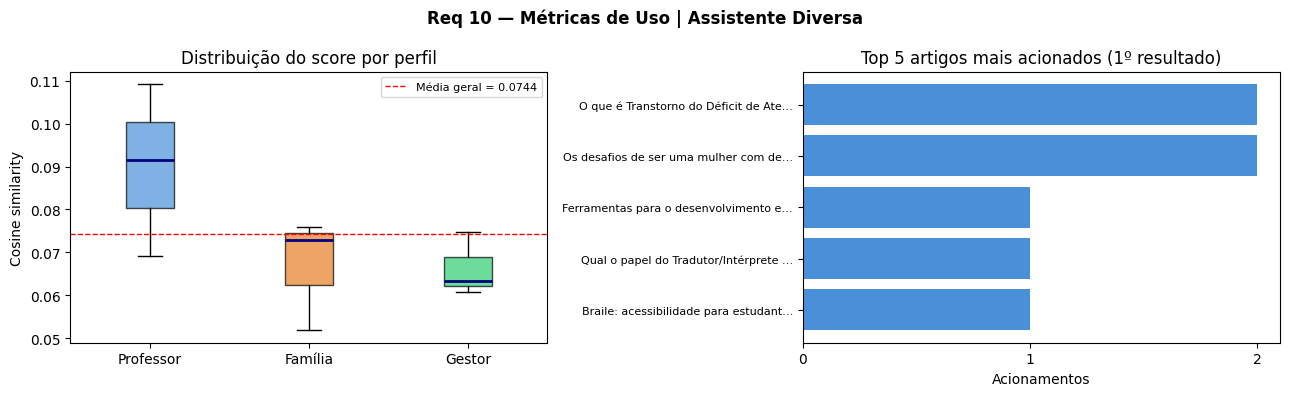

✅ Relatório gerado.


In [82]:
# ── Relatório de métricas ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt, matplotlib.ticker as mticker

media_geral   = df_metricas["score_similaridade"].mean()
mediana_geral = df_metricas["score_similaridade"].median()

# Top 5 artigos pelo titulo_artigo (melhor resultado de cada interação)
artigos_top = (
    df_metricas["titulo_artigo"]
    .pipe(lambda s: s[s != "—"])
    .value_counts()
    .head(5)
    .reset_index()
    .rename(columns={"titulo_artigo": "Artigo", "count": "N"})
)

# ── Tabela 1: Visão geral ─────────────────────────────────────────────────────
display(pd.DataFrame({
    "Métrica": ["Interações", "Período", "Score médio", "Mediana", "Score máx", "Score mín", "Sem artigo"],
    "Valor": [
        len(df_metricas),
        f"{df_metricas['timestamp'].min():%H:%M:%S} – {df_metricas['timestamp'].max():%H:%M:%S}",
        f"{media_geral:.4f}",
        f"{mediana_geral:.4f}",
        f"{df_metricas['score_similaridade'].max():.4f}",
        f"{df_metricas['score_similaridade'].min():.4f}",
        int((df_metricas['score_similaridade'] == 0).sum()),
    ]
}))

# ── Tabela 2: Estatísticas por perfil ────────────────────────────────────────
stats_por_perfil = df_metricas.groupby("perfil")["score_similaridade"].agg(
    Media="mean", Mediana="median", Max="max", Min="min"
).round(4).reset_index().rename(columns={"perfil": "Perfil"})
display(stats_por_perfil)

display(artigos_top)

# ── Gráficos ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Req 10 — Métricas de Uso | Assistente Diversa", fontweight="bold")

# Boxplot por perfil (mostra mediana, dispersão, máx e mín)
perfis = list(BATERIA.keys())
dados_boxplot = [df_metricas[df_metricas["perfil"] == p]["score_similaridade"].values
                 for p in perfis]
bp = ax1.boxplot(dados_boxplot, labels=perfis, patch_artist=True, medianprops={"color": "navy", "linewidth": 2})
cores = ["#4A90D9", "#E67E22", "#2ECC71"]
for patch, cor in zip(bp["boxes"], cores):
    patch.set_facecolor(cor); patch.set_alpha(0.7)
ax1.set_title("Distribuição do score por perfil")
ax1.set_ylabel("Cosine similarity")
ax1.axhline(media_geral, color="red", linestyle="--", linewidth=1,
            label=f"Média geral = {media_geral:.4f}")
ax1.legend(fontsize=8)

# Top 5 artigos
labels = [t[:36] + "…" if len(t) > 36 else t for t in artigos_top["Artigo"]]
ax2.barh(labels, artigos_top["N"], color="#4A90D9")
ax2.set_title("Top 5 artigos mais acionados (1º resultado)"); ax2.set_xlabel("Acionamentos")
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.set_yticks(range(len(artigos_top))); ax2.set_yticklabels(labels, fontsize=8)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("imagens_do_tcc/req10_metricas_uso.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Relatório gerado.")


## Requisito 11


**11. Experimentar embeddings semânticos**
  O TF-IDF não entende sinônimos — "criança cega" e "deficiência visual" são
  tratados como temas diferentes. Uma evolução natural é usar embeddings semânticos
  com modelos multilíngues gratuitos que entendem o significado
  das palavras, não apenas a forma.

### Resposta — Embeddings Semânticos via HuggingFace Inference API

In [83]:

import os
import numpy as np
import requests
from sklearn.metrics.pairwise import cosine_similarity

HF_TOKEN = os.getenv("HF_TOKEN", "")

HF_EMBEDDING_URL = (
    "https://router.huggingface.co/hf-inference/models/"
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/"
    "pipeline/feature-extraction"
)

HF_HEADERS = {
    "Authorization": f"Bearer {HF_TOKEN}",
    "Content-Type": "application/json",
}


def gerar_embeddings(textos: list, batch_size: int = 16) -> np.ndarray:
    """
    Envia textos para a HuggingFace Inference API e retorna uma matriz numpy
    de shape (N, 384), onde N é o número de textos.
    Processa em lotes para respeitar o limite da API gratuita.
    """
    todos_vetores = []

    for inicio in range(0, len(textos), batch_size):
        lote = textos[inicio : inicio + batch_size]
        payload = {"inputs": lote, "options": {"wait_for_model": True}}

        resp = requests.post(HF_EMBEDDING_URL, headers=HF_HEADERS, json=payload, timeout=30)

        if resp.status_code != 200:
            raise RuntimeError(f"Erro HF API [{resp.status_code}]: {resp.text[:200]}")

        todos_vetores.extend(resp.json())

    return np.array(todos_vetores, dtype=np.float32)


print("⏳ Gerando embeddings da base de artigos... (pode levar ~10s)")
textos_base = df["conteudo_busca"].tolist()
matriz_embeddings = gerar_embeddings(textos_base)

print(f"✅ Indexação semântica concluída!")
print(f"   Artigos indexados : {len(textos_base)}")
print(f"   Dimensões do vetor: {matriz_embeddings.shape[1]}")
print(f"   Shape da matriz   : {matriz_embeddings.shape}")


⏳ Gerando embeddings da base de artigos... (pode levar ~10s)
✅ Indexação semântica concluída!
   Artigos indexados : 20
   Dimensões do vetor: 384
   Shape da matriz   : (20, 384)


In [84]:

def buscar_artigos_semantico(pergunta: str, top_k: int = 3, score_minimo: float = 0.20) -> list:
    """
    Busca artigos usando similaridade semântica (embeddings).
    Entende sinônimos: 'criança cega' encontra 'deficiência visual'.
    Substitui buscar_artigos_relevantes() baseada em TF-IDF.
    """
    vetor_pergunta = gerar_embeddings([pergunta])          # shape (1, 384)
    scores = cosine_similarity(vetor_pergunta, matriz_embeddings)[0]
    indices = scores.argsort()[::-1][:top_k]

    resultados = []
    for i in indices:
        score = float(scores[i])
        if score >= score_minimo:
            resultados.append({
                "titulo": df.iloc[i]["titulo"],
                "url"   : df.iloc[i]["url"],
                "trecho": df.iloc[i]["texto_limpo"][:900],
                "score" : round(score, 4),
            })
    return resultados


PERGUNTAS_TESTE = [
    "criança cega na sala de aula",          # sinônimo de 'deficiência visual'
    "O que é Atendimento Educacional Especializado?",
    "direitos do estudante autista",
]

print("═" * 70)
print("COMPARATIVO: TF-IDF  vs  Embedding Semântico")
print("═" * 70)

for pergunta in PERGUNTAS_TESTE:
    res_tfidf    = buscar_artigos_relevantes(pergunta, top_k=3)
    res_semantico = buscar_artigos_semantico(pergunta, top_k=3)

    print(f"\n📌 Pergunta: '{pergunta}'")
    print(f"  TF-IDF     ({len(res_tfidf)} resultados):")
    for r in res_tfidf:
        print(f"    [{r['score']:.4f}] {r['titulo']}")

    print(f"  Semântico  ({len(res_semantico)} resultados):")
    for r in res_semantico:
        print(f"    [{r['score']:.4f}] {r['titulo']}")

print("\n✅ Comparativo concluído!")
print("   A função buscar_artigos_semantico() está pronta para substituir")
print("   buscar_artigos_relevantes() no pipeline principal (Seção 8).")


══════════════════════════════════════════════════════════════════════
COMPARATIVO: TF-IDF  vs  Embedding Semântico
══════════════════════════════════════════════════════════════════════

📌 Pergunta: 'criança cega na sala de aula'
  TF-IDF     (3 resultados):
    [0.1230] Qual o papel do Tradutor/Intérprete de Libras na escola inclusiva?
    [0.0870] Atendimento educacional especializado (AEE): pressupostos e desafios
    [0.0744] Flexibilizações vs. adaptações curriculares: como incluir alunos com deficiência intelectual
  Semântico  (3 resultados):
    [0.5412] Educação de surdos: os desafios da proposta bilíngue
    [0.4378] Atendimento educacional especializado (AEE): pressupostos e desafios
    [0.4272] Educação física como um meio para a inclusão social e qualidade de vida

📌 Pergunta: 'O que é Atendimento Educacional Especializado?'
  TF-IDF     (3 resultados):
    [0.1346] Atendimento educacional especializado (AEE): pressupostos e desafios
    [0.0804] A legislação federal bra

## Requisito 12


**12. Avaliar outros modelos gratuitos da Groq**
  Testar outros modelos também gratuitos na Groq, Llama, Hugging Face etc.)
  e comparar a qualidade das respostas em português com o modelo atual.
  Documentar a diferença de velocidade e qualidade.

### Resposta — Benchmark de Modelos na Groq

> **Nota:** O `llama-3.1-8b-instant` foi descontinuado em 25/06/2026 e substituído pelo `openai/gpt-oss-20b` como modelo principal do projeto.

In [85]:

import time
import pandas as pd

MODELOS_BENCHMARK = [
    {"id": "openai/gpt-oss-20b",         "nome": "GPT-OSS 20B",     "tier": "Production"},  # substituto oficial do llama-3.1-8b-instant (depreciado em 25/06/2026)
    {"id": "llama-3.3-70b-versatile",    "nome": "Llama 3.3 70B",   "tier": "Production"},
    {"id": "qwen/qwen3-32b",             "nome": "Qwen3 32B",       "tier": "Preview"},
]

PERGUNTAS_BENCHMARK = [
    ("Dentro do escopo",  "O que é tecnologia assistiva?"),
    ("Dentro do escopo",  "Como trabalhar com alunos com TDAH em sala?"),
    ("Fora do escopo",    "Qual é a capital da França?"),
    ("Sensível",          "Minha filha tem laudo de autismo, ela tem direito a quê na escola?"),
]


def chamar_modelo_benchmark(modelo_id: str, pergunta: str) -> dict:
    """
    Chama um modelo específico da Groq e mede tempo de resposta.
    Retorna dict com resposta, tempo e tokens estimados.
    """
    artigos = buscar_artigos_relevantes(pergunta, top_k=3)
    contexto = "\n\n".join(
        f"Artigo: {a['titulo']}\nTrecho: {a['trecho']}"
        for a in artigos
    ) or "Nenhum trecho relevante encontrado."

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": (
            f"TRECHOS DO PORTAL DIVERSA:\n{contexto}\n\n"
            f"PERGUNTA: {pergunta}"
        )},
    ]

    headers = {
        "Authorization": f"Bearer {GROQ_KEY}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": modelo_id,
        "messages": messages,
        "max_tokens": 400,
        "temperature": 0.3,
    }

    inicio = time.perf_counter()
    try:
        resp = requests.post(GROQ_URL, headers=headers, json=payload, timeout=45)
        tempo = round(time.perf_counter() - inicio, 2)

        if resp.status_code == 200:
            dados = resp.json()
            texto = dados["choices"][0]["message"]["content"].strip()
            tokens_saida = dados.get("usage", {}).get("completion_tokens", 0)
            return {"resposta": texto, "tempo_s": tempo, "tokens": tokens_saida, "erro": None}

        return {"resposta": "", "tempo_s": tempo, "tokens": 0, "erro": f"HTTP {resp.status_code}"}

    except Exception as e:
        tempo = round(time.perf_counter() - inicio, 2)
        return {"resposta": "", "tempo_s": tempo, "tokens": 0, "erro": str(e)}


registros = []

for categoria, pergunta in PERGUNTAS_BENCHMARK:
    print(f"\n📌 [{categoria}] {pergunta}")
    for modelo in MODELOS_BENCHMARK:
        resultado = chamar_modelo_benchmark(modelo["id"], pergunta)
        print(f"   {modelo['nome']:20s} → {resultado['tempo_s']}s | "
              f"{resultado['tokens']} tokens | "
              f"{'❌ ' + resultado['erro'] if resultado['erro'] else '✅'}")

        registros.append({
            "modelo"       : modelo["nome"],
            "modelo_id"    : modelo["id"],
            "tier"         : modelo["tier"],
            "categoria"    : categoria,
            "pergunta"     : pergunta,
            "tempo_s"      : resultado["tempo_s"],
            "tokens_saida" : resultado["tokens"],
            "resposta"     : resultado["resposta"],
            "erro"         : resultado["erro"] or "",
        })

df_benchmark = pd.DataFrame(registros)

print("\n" + "═" * 70)
print("✅ Benchmark concluído! Tabela salva em df_benchmark.")
print("   Preencha as colunas 'qualidade' e 'observacao' avaliando cada resposta.")
print("\n📊 Resumo por modelo (tempo médio e tokens médios):")
print(df_benchmark.groupby("modelo")[["tempo_s", "tokens_saida"]].mean().round(2))
display(df_benchmark[["modelo", "categoria", "tempo_s", "tokens_saida", "resposta"]])



📌 [Dentro do escopo] O que é tecnologia assistiva?
   GPT-OSS 20B          → 0.86s | 400 tokens | ✅
   Llama 3.3 70B        → 2.06s | 400 tokens | ✅
   Qwen3 32B            → 1.41s | 400 tokens | ✅

📌 [Dentro do escopo] Como trabalhar com alunos com TDAH em sala?
   GPT-OSS 20B          → 0.17s | 0 tokens | ❌ HTTP 429
   Llama 3.3 70B        → 1.74s | 400 tokens | ✅
   Qwen3 32B            → 1.34s | 400 tokens | ✅

📌 [Fora do escopo] Qual é a capital da França?
   GPT-OSS 20B          → 0.13s | 0 tokens | ❌ HTTP 429
   Llama 3.3 70B        → 0.64s | 27 tokens | ✅
   Qwen3 32B            → 0.79s | 167 tokens | ✅

📌 [Sensível] Minha filha tem laudo de autismo, ela tem direito a quê na escola?
   GPT-OSS 20B          → 0.14s | 0 tokens | ❌ HTTP 429
   Llama 3.3 70B        → 1.89s | 400 tokens | ✅
   Qwen3 32B            → 0.15s | 0 tokens | ❌ HTTP 429

══════════════════════════════════════════════════════════════════════
✅ Benchmark concluído! Tabela salva em df_benchmark.
   Preencha a

,modelo,categoria,tempo_s,tokens_saida,resposta
0,GPT-OSS 20B,Dentro do escopo,0.86,400,**Tecnologia Assistiva (TA)** \nÉ um conjunto...
1,Llama 3.3 70B,Dentro do escopo,2.06,400,A tecnologia assistiva é um conjunto de recurs...
2,Qwen3 32B,Dentro do escopo,1.41,400,"<think>\nOkay, the user is asking, ""O que é te..."
3,GPT-OSS 20B,Dentro do escopo,0.17,0,
4,Llama 3.3 70B,Dentro do escopo,1.74,400,Trabalhar com alunos com Transtorno do Déficit...
5,Qwen3 32B,Dentro do escopo,1.34,400,"<think>\nOkay, the user is asking how to work ..."
6,GPT-OSS 20B,Fora do escopo,0.13,0,
7,Llama 3.3 70B,Fora do escopo,0.64,27,Minha especialidade é Educação Inclusiva. Poss...
8,Qwen3 32B,Fora do escopo,0.79,167,"<think>\nOkay, the user is asking for the capi..."
9,GPT-OSS 20B,Sensível,0.14,0,
